# Full Waveform Inversion


1. https://arxiv.org/pdf/2110.07584 
2. https://wiki.seg.org/wiki/Full-waveform_inversion,_Part_1:_Forward_modeling?__cf_chl_tk=uwo63kyPgyJDGVJ8jEbsnc5mHDHzasvKd79btzLLuaY-1746946825-1.0.1.1-O8KNn6FHkqNPIELGgtdA1T216LG6LlLcko6_3hKTaAo#cite_note-5
3. https://epubs.siam.org/doi/pdf/10.1137/22M1540612?casa_token=TFZfJ8RyzNMAAAAA:_zyPLCxiAACkIdVx9sZNdevqvg5UWxuJzTwm3pstuhJWnqTA8hb_wZ5aelsqqNYBllScUotev3jV
4. https://antongrin.github.io/Seismika/Chapters/SignalProcessing/Ricker_wavelet.html
5. https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10319762
6. https://smileunc.github.io/publications
7. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial
8. https://www.kaggle.com/competitions/waveform-inversion/leaderboard
9. https://wiki.seg.org/wiki/Ricker_wavelet_relations
10. http://www.seismiccity.com/pdf/24_NonreflectingBoundary_1985.pdf
11. https://hal.science/hal-00799759/document
12. https://github.com/seg/tutorials-2017/blob/master/1712_FWI_forward_modeling/notebooks/modelling.ipynb
13. https://www.devitoproject.org/examples/seismic/tutorials/03_fwi.html


$$\Delta p(x,z,t) - \frac{1}{c^2(x,z)} \partial_t^2 p(x,z,t) - \eta(x,z) \partial_t p(x,z,t) = s(x,z,t; x_s,z_s).$$ 

Here $r$ is the Ricker wavelet with peak frequency $f_0$ 

$$r(t) = (1-2 \pi^2f_0^2t^2)e^{-\pi^2f_0^2t^2},$$ 

and $(x_s,z_s)$ the source location 

$$s(x,z,t; x_s,z_s) = r(t) \delta_{(x_s,z_s)}(x,z).$$


The dampening is

$$\eta(x,z) = \frac{3 \rho(x,z) c(x,z)}{2L^2} \log(R)$$

where $R = 10^{-7}$, $L$ is the overall thickness of absorbing layers, and $\rho(x,z)$ is the distance from $(x,z)$ to the nearest boundary of the original velocity map.

## Helmholtz Equation

Let $\hat{p}$ and $\hat{r}$ be the Fourier transforms of $p$ and $r$ respectively. Then 


$$p(x,z,t) = \sum_{k \in \mathbb{Z}} \hat{p}(x,z,k) e^{2 \pi \mathrm{i} tk}, \qquad \hat{p}(x,z,k) = \int_0^1 p(x,z,t) e^{-2 \pi \mathrm{i} t k} \mathrm{d} t$$

$$r(t) = \sum_{k \in \mathbb{Z}} \hat{r}(k) e^{2 \pi \mathrm{i} tk}, \qquad \hat{r}(k) = \int_0^1 (1-2 \pi^2f_0^2t^2)e^{-\pi^2f_0^2t^2} e^{-2 \pi \mathrm{i} t k} \mathrm{d} t$$


Let $b = \log(c)$ and $\gamma = \frac{3}{2L^2} \log(R)$. Then

$$\Delta \hat{p}(x,z,k) + (2 \pi k)^2 e^{-2b(x,z)} \hat{p}(x,z,k) - (2 \pi \mathsf{i} k) \gamma \rho(x,z) e^{b(x,z)} \hat{p}(x,z,k) = \hat{r}(k) \delta_{(x_s,z_s)}(x,z), \qquad \forall k \in \mathbb{Z}$$



## Depth Stepping

$$\frac{\hat{p}_{i+1}(x,z,k) - 2 \hat{p}_i(x,z,k) + \hat{p}_{i-1}(x,z,k)}{(\Delta z)^2} + \partial_x^2 \hat{p}_{i+1}(x,z,k) + (2 \pi k)^2 e^{-2b(x,z)} \hat{p}_{i+1}(x,z,k) - (2 \pi \mathsf{i} k) \gamma \rho(x,z) e^{b(x,z)} \hat{p}_{i+1}(x,z,k) = \hat{r}(k) \delta_{(x_s,z_s)}(x,z), \qquad \forall k \in \mathbb{Z}$$

$$\mathcal{F}(\hat{p}_{i+1}, b; \hat{p}_i,\hat{p}_{i-1}) = \hat{p}_{i+1} - 2 \hat{p}_i + \hat{p}_{i-1} + (\Delta z)^2\left[\partial_x^2 \hat{p}_{i+1} + (2 \pi k)^2 e^{-2b} \hat{p}_{i+1} - (2 \pi \mathrm{i} k) \gamma \rho e^b \hat{p}_{i+1} - \hat{r} \delta_{(x_s,z_s)}\right] = 0$$

Letting 

$$\hat{p} = u + \mathrm{i} v, \qquad \hat{r} = \hat{r}_\mathrm{real} + \mathrm{i}\hat{r}_\mathrm{imag}$$

we have

$$\mathcal{F}_\mathrm{real}(u_{i+1}, v_{i+1}, b; u_i,v_i,u_{i-1},v_{i-1}) = u_{i+1} - 2 u_i + u_{i-1} + (\Delta z)^2\left[\partial_x^2 u_{i+1} + (2 \pi k)^2 e^{-2b} u_{i+1} + (2 \pi k) \gamma \rho e^b v_{i+1} - \hat{r}_\mathrm{real} \delta_{(x_s,z_s)}\right] = 0$$

$$\mathcal{F}_\mathrm{imag}(u_{i+1}, v_{i+1}, b; u_i,v_i,u_{i-1},v_{i-1}) = v_{i+1} - 2 v_i + v_{i-1} + (\Delta z)^2\left[\partial_x^2 v_{i+1} + (2 \pi k)^2 e^{-2b} v_{i+1} - (2 \pi k) \gamma \rho e^b u_{i+1} - \hat{r}_\mathrm{imag} \delta_{(x_s,z_s)}\right] = 0$$

The real parts are 

$$\left[\frac{\delta \mathcal{F}_\mathrm{real}}{\delta u_{i+1}}(u_{i+1},v_{i+1},b; u_i,v_i,u_{i-1},v_{i-1})\right](h) = h + (\Delta z)^2\left[\partial_x^2h + (2 \pi k)^2 e^{-2b} h\right]$$

$$\left[\frac{\delta \mathcal{F}_\mathrm{real}}{\delta v_{i+1}}(u_{i+1},v_{i+1},b; u_i,v_i,u_{i-1},v_{i-1})\right](h) = (\Delta z)^2 (2 \pi k) \gamma \rho e^b h$$

$$\left[\frac{\delta \mathcal{F}_\mathrm{real}}{\delta b}(u_{i+1},v_{i+1},b; u_i,v_i,u_{i-1},v_{i-1})\right](h) = (\Delta z)^2 \left[-2 (2 \pi k)^2 e^{-2b} u_{i+1}h + (2 \pi k) \gamma \rho e^b v_{i+1} h\right]$$

and the imaginary parts are

$$\left[\frac{\delta \mathcal{F}_\mathrm{imag}}{\delta u_{i+1}}(u_{i+1},v_{i+1},b; u_i,v_i,u_{i-1},v_{i-1})\right](h) = - (\Delta z)^2(2 \pi k) \gamma \rho e^b h$$

$$\left[\frac{\delta \mathcal{F}_\mathrm{imag}}{\delta v_{i+1}}(u_{i+1},v_{i+1},b; u_i,v_i,u_{i-1},v_{i-1})\right](h) = h + (\Delta z)^2\left[\partial_x^2h + (2 \pi k)^2 e^{-2b} h\right]$$

$$\left[\frac{\delta \mathcal{F}_\mathrm{imag}}{\delta b}(u_{i+1},v_{i+1},b; u_i,v_i,u_{i-1},v_{i-1})\right](h) = (\Delta z)^2 \left[-2 (2 \pi k)^2 e^{-2b} v_{i+1}h - (2 \pi k) \gamma \rho e^b u_{i+1} h\right]$$



The discretized maps for the real part are  

$$\frac{\delta \mathcal{F}_\mathrm{real}}{\delta u_{i+1}} = \mathsf{I} + (\Delta z)^2 \left[A_x + (2 \pi k)^2 \mathrm{diag}(e^{-2b})\right]$$

$$\frac{\delta \mathcal{F}_\mathrm{real}}{\delta v_{i+1}} = (\Delta z)^2 (2 \pi k) \gamma \mathrm{diag}(\rho \odot e^b)$$

$$\frac{\delta \mathcal{F}_\mathrm{real}}{\delta b} = (\Delta z)^2 \left[-2(2 \pi k)^2\mathrm{diag}(e^{-2b} \odot u_{i+1}) + (2 \pi k) \gamma \mathrm{diag}(\rho \odot e^b \odot v_{i+1})\right]$$

and for the imaginary part are 

$$\frac{\delta \mathcal{F}_\mathrm{imag}}{\delta u_{i+1}} = -(\Delta z)^2 (2 \pi k) \gamma \mathrm{diag}(\rho \odot e^b)$$

$$\frac{\delta \mathcal{F}_\mathrm{imag}}{\delta v_{i+1}} = \mathsf{I} + (\Delta z)^2 \left[A_x + (2 \pi k)^2 \mathrm{diag}(e^{-2b})\right]$$

$$\frac{\delta \mathcal{F}_\mathrm{imag}}{\delta b} = (\Delta z)^2 \left[-2(2 \pi k)^2\mathrm{diag}(e^{-2b} \odot v_{i+1}) - (2 \pi k) \gamma \mathrm{diag}(\rho \odot e^b \odot u_{i+1})\right]$$


## Setup

In [101]:
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import pyKoLesky.cholesky
import qmcpy as qp 

In [102]:
torch.set_default_dtype(torch.float64)
assert torch.cuda.is_available()
torch.manual_seed(17)
DEVICE = "cuda"

In [103]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi.ipynb")

In [104]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

## Load Dataset

In [105]:
velocity = torch.from_numpy(np.load('train_samples/FlatVel_A/model/model2.npy')).to(torch.get_default_dtype()) # [km/s]
wavefield = torch.from_numpy(np.load('train_samples/FlatVel_A/data/data2.npy')).to(torch.get_default_dtype()) # 
print("velocity.shape = %s"%str(tuple(velocity.shape)))
print("velocity.dtype = %s"%str(velocity.dtype))
print("wavefield.shape = %s"%str(tuple(wavefield.shape)))
print("wavefield.dtype = %s"%str(wavefield.dtype))

velocity.shape = (500, 1, 70, 70)
velocity.dtype = torch.float64
wavefield.shape = (500, 5, 1000, 70)
wavefield.dtype = torch.float64


## Parameters

In [106]:
#dx = dz = 10 # [m] 
dx = dz = 10/1000 # [km] 
dt = 0.001 # [s]
Nx = velocity.size(-1) 
Nz = velocity.size(-2)
Nt = wavefield.size(-2)
S = wavefield.size(1)
xticks = torch.linspace(0,Nx*dx,Nx,device=DEVICE)
zticks = torch.linspace(0,Nz*dz,Nz,device=DEVICE)
tticks = torch.linspace(0,Nt*dt,Nt,device=DEVICE)
ricker_peak_freq = 15 # [Hz]
Na = 10#120
assert Na<Nx/2 and Na<Nz/2
_L_damp = Na*dx
_R_damp = 10**(-7)
#GAMMA = 3/(2*_L_damp**2)*np.log(_R_damp)
#GAMMA = 3/(2*_L_damp**2)*np.log(_R_damp)/1000
GAMMA = 0 # no dampening
print("GAMMA = %.1e"%GAMMA)

GAMMA = 0.0e+00


## Data 

### Dirac Deltas for Sources

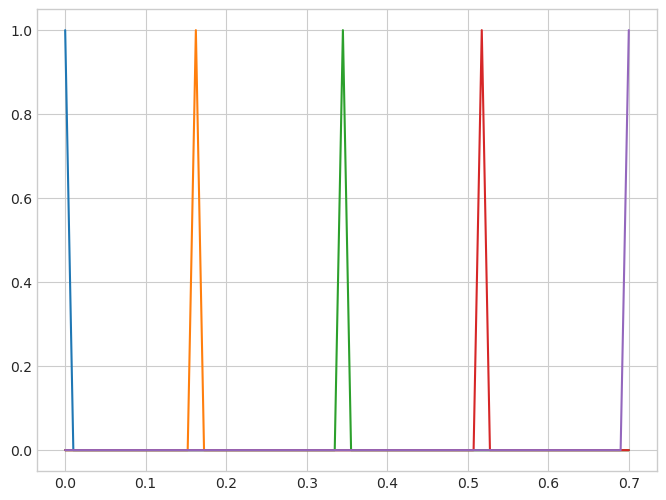

In [107]:
dirac_s_all = torch.zeros((S,Nx),device=DEVICE)
for i in range(S):
    dirac_s_all[i,max(int(i*Nx/(S-1))-1,0)] = 1
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(8,6))
for i in range(S):
    ax.plot(xticks.cpu(),dirac_s_all[i].cpu())

### Velocity and Wavefield Visualization

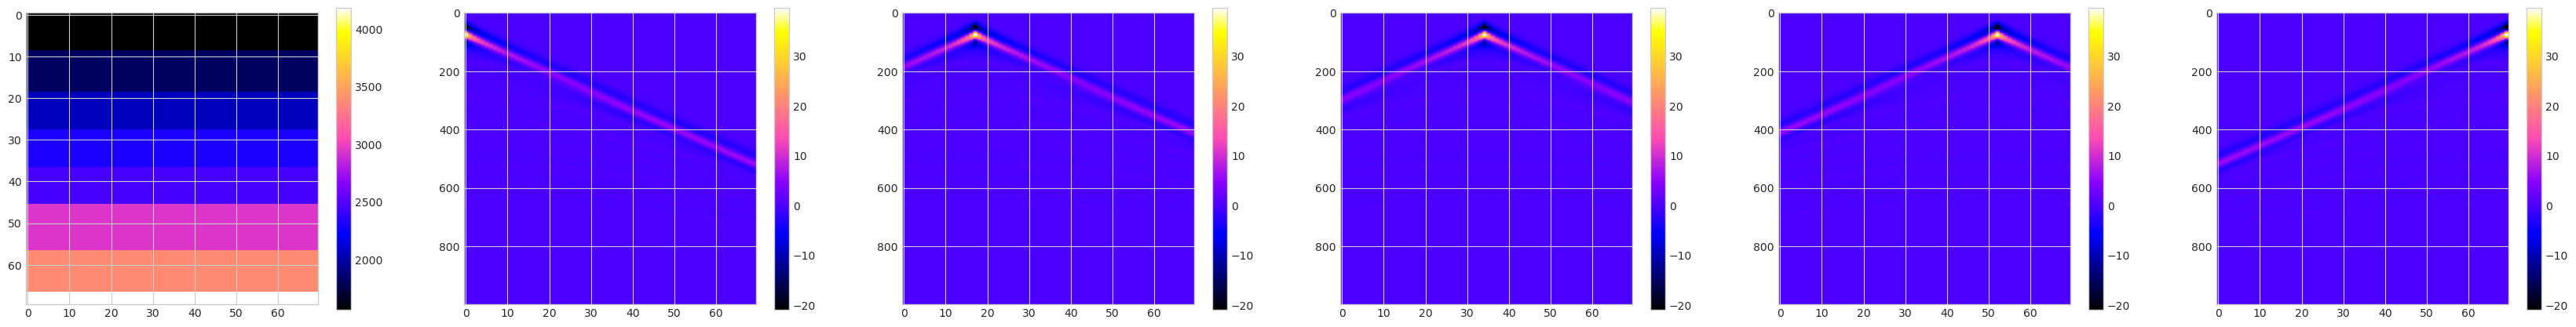

In [108]:
nrows = 1
ncols = 1+S
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(7*ncols,5*nrows))
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for i in range(nrows):
    cax = ax[i,0].imshow(velocity[i,0],vmin=velocity[i,0].min(),vmax=velocity[i,0].max(),cmap=cm.gnuplot2)
    fig.colorbar(cax)
    for j in range(ncols-1):
        cax = ax[i,j+1].imshow(wavefield[i,j],cmap=cm.gnuplot2)
        ax[i,j+1].set_aspect(Nx/Nt)
        fig.colorbar(cax)

### Dampening Boundary Distances

rho.shape = torch.Size([70, 70])


(tensor(0.7000, device='cuda:0'), 0.1, 0.6)

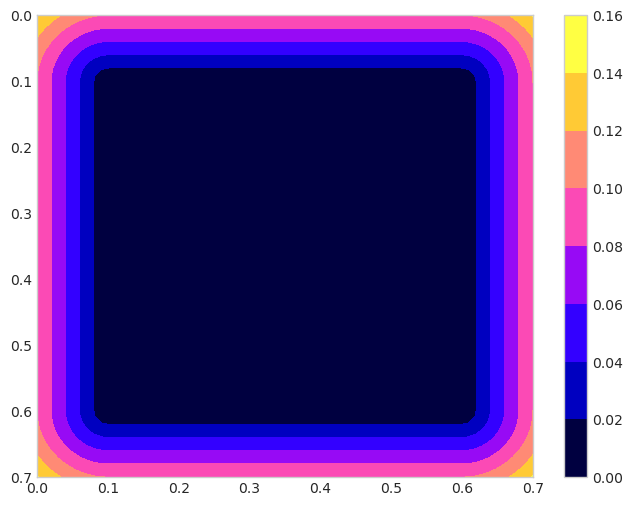

In [109]:
xzmesh_z,xzmesh_x = torch.meshgrid(zticks,xticks,indexing="ij")
rho = torch.zeros_like(xzmesh_z)
rho[:Na,Na:-Na] = Na*dz-xzmesh_z[:Na,Na:-Na] # top
rho[-Na:,Na:-Na] = xzmesh_z[-Na:,Na:-Na]-(Nz-Na)*dz # bottom
rho[Na:-Na,:Na] = Na*dx-xzmesh_x[Na:-Na,:Na] # left
rho[Na:-Na,-Na:] = xzmesh_x[Na:-Na,-Na:]-(Nx-Na)*dx # right
rho[:Na,:Na] = torch.sqrt((xzmesh_z[:Na,:Na]-Na*dz)**2+(xzmesh_x[:Na,:Na]-Na*dx)**2) # top left
rho[:Na,-Na:] = torch.sqrt((xzmesh_z[:Na,-Na:]-Na*dz)**2+(xzmesh_x[:Na,-Na:]-(Nx-Na)*dx)**2) # top right
rho[-Na:,:Na] = torch.sqrt((xzmesh_z[-Na:,:Na]-(Nz-Na)*dz)**2+(xzmesh_x[-Na:,:Na]-Na*dx)**2) # top right
rho[-Na:,-Na:] = torch.sqrt((xzmesh_z[-Na:,-Na:]-(Nz-Na)*dz)**2+(xzmesh_x[:Na,-Na:]-(Nx-Na)*dx)**2) # bottom right
print("rho.shape = %s"%str(rho.shape))
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(8,6))
cax = ax.contourf(xzmesh_x.cpu(),xzmesh_z.cpu(),rho.cpu(),cmap=cm.gnuplot2)
ax.invert_yaxis()
fig.colorbar(cax)
xzmesh_z.max(),Na*dz,(Nz-Na)*dz

### Ricker Wavelet

ricker_wavelet.shape = (1000,)
ricker_wavelet.dtype = torch.float64
rhat.shape = (501,)
rhat.dtype = torch.complex128
Nf = 501
_ricker_wavelet_reconstruct.imag.abs().max() = 0.25


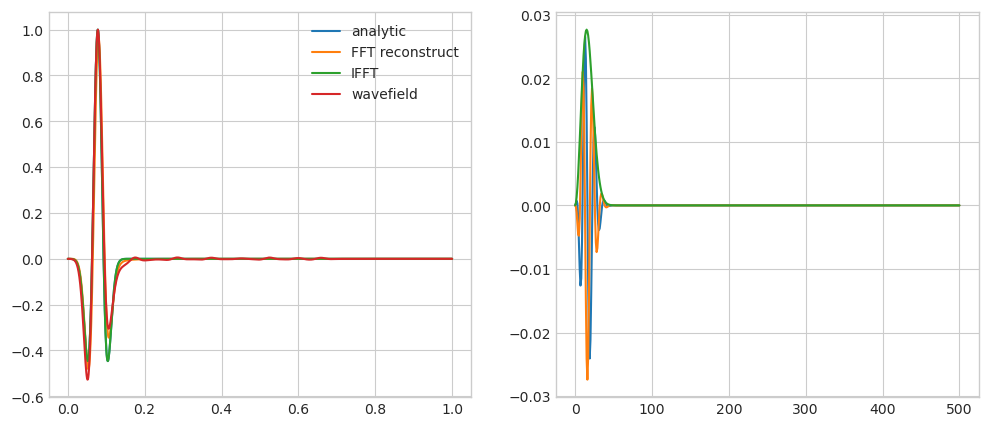

In [110]:
ricker_wavelet_shift = 78*dt
ricker_wavelet_scale = 1
#ricker_wavelet_scale = 40
ricker_wavelet = ricker_wavelet_scale*(1-2*(np.pi*ricker_peak_freq*(tticks-ricker_wavelet_shift))**2)*torch.exp(-(np.pi*ricker_peak_freq*(tticks-ricker_wavelet_shift))**2)
print("ricker_wavelet.shape = %s"%str(tuple(ricker_wavelet.shape)))
print("ricker_wavelet.dtype = %s"%str(ricker_wavelet.dtype))
rhat = torch.fft.rfft(ricker_wavelet,norm="forward").to(DEVICE)
_rhat_full = torch.fft.fft(ricker_wavelet,norm="forward").to(DEVICE)
print("rhat.shape = %s"%str(tuple(rhat.shape)))
print("rhat.dtype = %s"%str(rhat.dtype))
Nf = len(rhat)
print("Nf = %d"%Nf)
_basis = torch.exp(2*torch.pi*1j*torch.arange(Nt,device=DEVICE)[:,None]*tticks)
_ricker_wavelet_reconstruct = (_rhat_full[:,None]*_basis).sum(0)
print("_ricker_wavelet_reconstruct.imag.abs().max() = %.2f"%_ricker_wavelet_reconstruct.imag.abs().max())
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(12,5))
ax[0].plot(tticks.cpu(),ricker_wavelet.cpu(),label="analytic");
ax[0].plot(tticks.cpu(),_ricker_wavelet_reconstruct.real.cpu(),label="FFT reconstruct");
ax[0].plot(tticks.cpu(),torch.fft.irfft(rhat,norm="forward").real.cpu(),label="IFFT");
ax[0].plot(tticks.cpu(),wavefield[0,0,:,0]/wavefield[0,0,:,0].max()*ricker_wavelet_scale,label="wavefield")
ax[0].legend(frameon=False)
ax[1].plot(rhat.real.cpu())
ax[1].plot(rhat.imag.cpu())
ax[1].plot(rhat.abs().cpu());
#ax[0].set_xlim([0.06,.09]);

## Gauss Newton Solver

### Gauss Newton Function

In [ ]:
def pde_solve(
        p0, 
        b,
        dirac_s,
        num_newton_iter = 6, 
        relaxation = 0, 
        lr = 1, 
        line_search = False, 
        line_search_c1 = 1e-4, 
        line_search_beta = .3,
        line_search_min_lr = 1e-16,
        pref = None, 
        predict_Linvs = None, 
        store_Linvs = False, 
        verbose = True,
        vverbose = True,
        verbose_indent = 4,
        relaxation_to_store = None):
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    # timing setup
    t0 = torch.cuda.Event(enable_timing=True)
    tend = torch.cuda.Event(enable_timing=True)
    t0.record()
    # input shape varification
    assert p0.ndim==3
    assert b.ndim==3
    assert dirac_s.ndim==2
    R = len(p0) 
    assert p0.shape==(R,Nt,Nx)
    assert b.shape==(R,Nz,Nx)
    assert dirac_s.shape==(R,Nx)
    # reference solution setup
    assert pref is None or pref=="last" or isinstance(pref,torch.Tensor)
    eyeNx = torch.eye(Nx,device=DEVICE)
    eyeNx2 = torch.eye(2*Nx,device=DEVICE)
    onesNx = torch.ones(Nx,device=DEVICE)
    onesNf = torch.ones(Nf,device=DEVICE)
    onesR = torch.ones(R,device=DEVICE)
    Nxr = torch.arange(Nx,device=DEVICE)
    Nxr2 = torch.arange(2*Nx,device=DEVICE)
    k = torch.arange(Nf,device=DEVICE)
    k_full = onesR[:,None]*k # k_full.shape==(R,Nf)
    rhat_full = onesR[:,None]*rhat # rhat_full.shape==(R,Nf)
    # finite difference for \partial_x^2 
    Ax = torch.zeros((Nx,Nx),device=DEVICE)
    Ax[Nxr,Nxr] = -2 
    Ax[Nxr[1:],Nxr[:-1]] = 1
    Ax[Nxr[:-1],Nxr[1:]] = 1
    #    u_{-1}=u_0 and u_N = u_{N-1}
    Ax[0,0] = -1 # for u_{-1} - 2 u_0 + u_1 assume u_{-1} = u_0 so we have -u_0 + u_1
    Ax[-1,-1] = -1 # for u_{N-1} - 2 u_N + u_{N+1} assume u_{N+1} = u_N so we have u_{N-1} - u_N
    #    periodic 
    # Ax[0,-1] = 1
    # Ax[-1,0] = 1
    Ax = Ax/dx**2
    # storage
    ps = torch.zeros((R,Nz,num_newton_iter+1,Nt,Nx))
    resid = torch.empty((R,Nz,num_newton_iter+1,Nf,Nx,2))
    rmse_resid = torch.empty((R,Nz,num_newton_iter+1))
    times = torch.empty((Nz,num_newton_iter+1))
    if store_Linvs:
        assert False, "not yet implemented"
        Linvs = torch.zeros((R,Nz,num_newton_iter,Nf,2*Nx,2*Nx))
    if line_search:
        lr_lss = torch.zeros((R,Nz,num_newton_iter,Nf))
    if isinstance(pref,torch.Tensor):
        assert False, "not yet implemented"
        assert pref.shape==(R,Nz,Nt,Nx)
        # pref_norm.shape==(R,Nt)
        prefnorm = torch.linalg.norm(pref[:,:,None,:,:],dim=(-2,-1))
        l2rerrors = torch.zeros((R,Nz,num_newton_iter+1))
    ps[:,0,:,:,:] = p0[:,None,:,:].cpu()
    p0hat = torch.fft.rfft(p0.to(DEVICE),norm="forward",dim=-2)
    # uv{n1,0,1}.shape == (R,Nf,2*Nx)
    uv1 = torch.cat([p0hat.real,p0hat.imag],dim=-1)
    uv0 = uv1.clone()
    uvn1 = uv1.clone()
    # uv0 = torch.zeros_like(uv1)
    # uvn1 = torch.zeros_like(uv1)
    for zeta in range(1,Nz):
        verbose_t = verbose and ((zeta+1)%vverbose==0 or zeta==(Nz-1))
        if verbose_t:
            _vstr = "depth step %d of %d: z = %-15.2f"%(zeta+1,Nz,zticks[zeta])
            print(" "*verbose_indent+_vstr)
            print(" "*verbose_indent+"-"*len(_vstr))
            _vstr = "%-15s| %-10s| %-52s|"%("iter of %-6d"%num_newton_iter,"time","RMSE residual")
            if isinstance(pref,torch.Tensor):
                _vstr += " %-52s|"%"L2 relative error"
            print(" "*(verbose_indent+4)+_vstr)
            _vstr = "%-15s| %-10s| %-13s%-13s%-13s%-13s|"%(" "*15," "*10,"5%","median","mean","95%")
            if isinstance(pref,torch.Tensor):
                _vstr += " %-13s%-13s%-13s%-13s|"%("5%","median","mean","95%")
            print(" "*(verbose_indent+4)+_vstr)
            print(" "*(verbose_indent+4)+"-"*len(_vstr))
        rho_z = rho[zeta,:] # rho_z.shape==(Nx)
        b_z = b[:,zeta,:] # b_z.shape==(R,Nx)
        b_z_full = b_z[:,None,:]*onesNf[:,None] # b_z_full.shape==(R,Nf,Nx)
        dirac_s_z = dirac_s if zeta==0 else torch.zeros_like(dirac_s) # dirac_s_z.shape==(R,Nx)
        dirac_s_z_full = dirac_s_z[:,None,:]*onesNf[:,None] # dirac_s_z_full.shape==(R,Nf,Nx)
        def F(u1, v1, u0, v0, un1, vn1, k, b_z, dirac_s_z, rhat):
            _bs = tuple(u1.shape[:-1])
            assert u1.shape==_bs+(Nx,)
            assert v1.shape==_bs+(Nx,)
            assert u0.shape==_bs+(Nx,)
            assert v0.shape==_bs+(Nx,)
            assert un1.shape==_bs+(Nx,)
            assert vn1.shape==_bs+(Nx,)
            assert k.shape==_bs
            assert b_z.shape==_bs+(Nx,)
            assert dirac_s_z.shape==_bs+(Nx,)
            assert rhat.shape==_bs
            _const1 = (2*torch.pi*k[...,None])**2*torch.exp(-2*b_z)
            _const2 = (2*torch.pi*k[...,None])*GAMMA*rho_z*torch.exp(b_z)
            _const3 = rhat[...,None]*dirac_s_z
            # real part
            #Ax_u1 = torch.einsum("ij,...j->...i",Ax,u1)
            #F_real = u1-2*u0+un1+dz**2*(Ax_u1+_const1*u1+_const2*v1-_const3.real)
            Ax_u0 = torch.einsum("ij,...j->...i",Ax,u1)
            F_real = u1-2*u0+un1+dz**2*(Ax_u0+_const1*u0+_const2*v0-_const3.real)
            assert F_real.shape==_bs+(Nx,)
            # imaginary part
            #Ax_v1 = torch.einsum("ij,...j->...i",Ax,v1)
            #F_imag = v1-2*v0+vn1+dz**2*(Ax_v1+_const1*v1-_const2*u1-_const3.imag)
            Ax_v0 = torch.einsum("ij,...j->...i",Ax,v1)
            F_imag = v1-2*v0+vn1+dz**2*(Ax_v0+_const1*v0-_const2*u0-_const3.imag)
            assert F_imag.shape==_bs+(Nx,)
            # combined
            F_real_imag = torch.cat([F_real,F_imag],dim=-1)
            assert F_real_imag.shape==_bs+(2*Nx,)
            return F_real_imag
        def partial_F(u1, v1, u0, v0, un1, vn1):
            #dFreal_du1 = eyeNx+dz**2*(Ax+(2*torch.pi*k[:,None,None])**2*torch.exp(-2*b_z[:,None,:,None]))
            dFreal_du1 = eyeNx+dz**2*(Ax+(2*torch.pi*k[:,None,None])**2*torch.exp(-2*b_z[:,None,:,None]))
            assert dFreal_du1.shape==(R,Nf,Nx,Nx)
            dFreal_dv1 = dz**2*(2*torch.pi*k[:,None,None])*GAMMA*rho_z[:,None]*torch.exp(b_z[:,None,:,None])
            assert dFreal_dv1.shape==(R,Nf,Nx,1)
            dFreal_dv1 = dFreal_dv1*onesNx
            dFimag_du1 = -dFreal_dv1
            dFimag_dv1 = dFreal_du1
            dF = torch.cat([torch.cat([dFreal_du1,dFreal_dv1],dim=-1),torch.cat([dFimag_du1,dFimag_dv1],dim=-1)],dim=-2)
            #dF = torch.cat([torch.cat([dFreal_du1,dFreal_dv1],dim=-2),torch.cat([dFimag_du1,dFimag_dv1],dim=-2)],dim=-1)
            assert dF.shape==(R,Nf,2*Nx,2*Nx)
            return dF
        residual = F(uv1[...,:Nx],uv1[...,Nx:],uv0[...,:Nx],uv0[...,Nx:],uvn1[...,:Nx],uvn1[...,Nx:],k_full,b_z_full,dirac_s_z_full,rhat_full)
        for i in range(num_newton_iter+1):
            ps[:,zeta,i,:,:] = torch.fft.irfft(uv1[...,:Nx]+1j*uv1[...,Nx:],norm="forward",dim=-2).cpu()
            resid[:,zeta,i,:,:,0] = residual[...,:Nx].cpu()
            resid[:,zeta,i,:,:,1] = residual[...,Nx:].cpu()
            rmse_resid[:,zeta,i] = torch.sqrt(torch.mean(resid[:,zeta,i,:,:,:]**2,(-3,-2,-1)))
            if isinstance(pref,torch.Tensor):
                assert False, "not yet implemented"
                l2rerrors[:,zeta,i] = torch.linalg.norm(ps[:,zeta,i,:,:]-pref[:,zeta,:,:],dim=(-2,-1))/prefnorm[:,zeta]
            tend.record()
            torch.cuda.synchronize()
            times[zeta,i] = t0.elapsed_time(tend)/1000/R
            t0 = torch.cuda.Event(enable_timing=True)
            tend = torch.cuda.Event(enable_timing=True)
            t0.record()
            verbose_i = verbose and (i%verbose==0 or i==num_newton_iter)
            if verbose_i and verbose_t:
                _vstr = "%-15d| %-10.2e| %-13.2e%-13.2e%-13.2e%-13.2e|"%(i,times[zeta,i]*R,
                        torch.quantile(rmse_resid[:,zeta,i],.05),torch.quantile(rmse_resid[:,zeta,i],.5),torch.mean(rmse_resid[:,zeta,i]),torch.quantile(rmse_resid[:,zeta,i],.95))
                if isinstance(pref,torch.Tensor):
                    _vstr += " %-13.2e%-13.2e%-13.2e%-13.2e|"%(
                        torch.quantile(l2rerrors[:,zeta,i],.05),torch.quantile(l2rerrors[:,zeta,i],.5),torch.mean(l2rerrors[:,zeta,i]),torch.quantile(l2rerrors[:,zeta,i],.95))
                print(" "*(verbose_indent+4)+_vstr)
            if i==num_newton_iter: break
            dFduv = partial_F(uv1[...,:Nx],uv1[...,Nx:],uv0[...,:Nx],uv0[...,Nx:],uvn1[...,:Nx],uvn1[...,Nx:]) # shape (R,Nf,2*Nx,2*Nx)
            if predict_Linvs is None: 
                # Theta.shape==(R,Nf,2*Nx,2*Nx)
                Theta = torch.einsum("rtki,rtkj->rtij",dFduv,dFduv) # batch dFduv[r,t].T@dFduv[r,t]
                Theta[:,:,Nxr2,Nxr2] = Theta[:,:,Nxr2,Nxr2]+relaxation # add to diagonals
                # L.shape==Linv.shape==(R,Nf,2*Nx,2*Nx)
                L = torch.linalg.cholesky(Theta,upper=False)
                Linv = torch.linalg.solve_triangular(L,eyeNx2,upper=False)
            else:
                assert False, "have not considered this yet"
                Linv = predict_Linvs(v)
            if store_Linvs:
                assert False, "storing Linvs may be too large, check size before doing this"
                Linvs[:,zeta,i,:,:,:] = Linv
            # _b.shape==delta.shape==v_new.shape==residual.shape==(R,Nx)
            _b = torch.einsum("rtik,rti->rtk",dFduv,residual)
            delta = torch.einsum("rtik,rti->rtk",Linv,torch.einsum("rtik,rtk->rti",Linv,_b)) # batch Linv[r,t].T@(Linv[r,t]@_b[r,t])
            uv1_new = uv1-lr*delta
            residual_new = F(uv1_new[...,:Nx],uv1_new[...,Nx:],uv0[...,:Nx],uv0[...,Nx:],uvn1[...,:Nx],uvn1[...,Nx:],k_full,b_z_full,dirac_s_z_full,rhat_full)
            if line_search:
                uv1_clone = uv1.clone()
                residual_clone = residual.clone()
                mask = torch.ones((R,Nf),dtype=bool,device=DEVICE)
                lr_ls = lr*torch.ones((R,Nf),device=DEVICE)
                _temp1 = torch.linalg.norm(residual,dim=-1)**2
                _temp2 = 2*line_search_c1*(_b*delta).sum(-1)
                while True:
                    _mask = mask.clone()
                    mask[_mask] = (torch.linalg.norm(residual_new[_mask],dim=-1)**2)>(_temp1[_mask]+lr_ls[_mask]*_temp2[_mask])
                    if mask.sum()==0: break 
                    if lr_ls[mask].min()<=line_search_min_lr:
                        uv1_new[mask] = uv1_clone[mask]
                        residual_new[mask] = residual_clone[mask]
                        break
                    lr_ls[mask] = lr_ls[mask]*line_search_beta
                    uv1_new[mask] = uv1[mask]-lr_ls[mask][...,None]*delta[mask]
                    residual_new[mask] = F(uv1_new[mask][...,:Nx],uv1_new[mask][...,Nx:],uv0[mask][...,:Nx],uv0[mask][...,Nx:],uvn1[mask][...,:Nx],uvn1[mask][...,Nx:],k_full[mask],b_z_full[mask],dirac_s_z_full[mask],rhat_full[mask])
                lr_lss[:,zeta,i,:] = lr_ls.cpu()
            uv1 = uv1_new 
            residual = residual_new
        if zeta==2: break#assert False
        uvn1 = uv0.clone()
        uv0 = uv1.clone()
    data = {"ps":ps,"resid":resid,"rmse_resid":rmse_resid,"times":torch.cumsum(times.flatten(),0).reshape((Nz,num_newton_iter+1))}
    if store_Linvs:
        assert False, "have not considered how to store Linvs yet "
        data["Linvs"] = Linvs
    if line_search:
        data["lr_lss"] = lr_lss
    if pref=="last":
        pref = ps[:,:,-1,:,:]
        l2rerrors = torch.linalg.norm(ps-pref[:,:,None,:,:],dim=(-2,-1))/torch.linalg.norm(pref[:,:,None,:,:],dim=(-2,-1))
    if pref is not None:
        data["l2rerrors"] = l2rerrors
    return ps,data

### Gauss Newton Solves

    depth step 2 of 70: z = 0.01           
    ---------------------------------------
        iter of 5      | time      | RMSE residual                                       |
                       |           | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------
        0              | 1.72e-01  | 4.84e-02     4.88e-02     4.92e-02     5.12e-02     |
        1              | 7.37e-02  | 4.36e-02     4.39e-02     4.43e-02     4.61e-02     |
        2              | 7.17e-02  | 3.92e-02     3.95e-02     3.99e-02     4.15e-02     |
        3              | 7.10e-02  | 3.53e-02     3.56e-02     3.59e-02     3.73e-02     |
        4              | 7.10e-02  | 3.18e-02     3.20e-02     3.23e-02     3.36e-02     |
        5              | 7.07e-02  | 2.86e-02     2.88e-02     2.91e-02     3.02e-02     |
    depth step 3 of 70: z = 0.02           
    ---------------------------------------
     

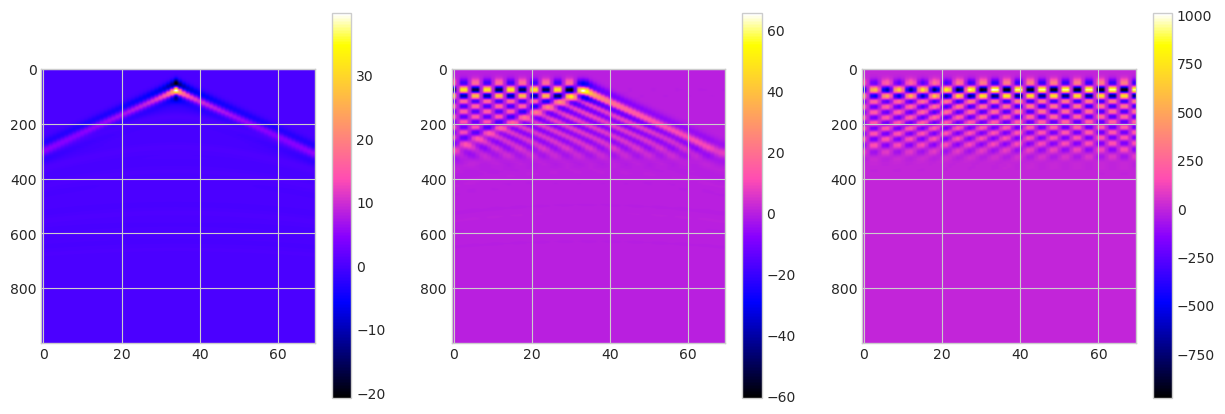

In [115]:
ps,data = pde_solve(
    p0 = wavefield[:25,2,:,:].to(DEVICE),
    b = torch.log(velocity[:25,0,:,:]).to(DEVICE),
    dirac_s = torch.tile(dirac_s_all[None,2,:],(25,1)).to(DEVICE),
    num_newton_iter = 5,
    relaxation = 1e-5,
    lr = 1e-1,
    line_search = False)
fig,ax = pyplot.subplots(nrows=1,ncols=3,figsize=(3*5,5))
for i in range(3):
    cax = ax[i].imshow(ps[0,i,-1,:,:],cmap=cm.gnuplot2)
    fig.colorbar(cax)
    ax[i].set_aspect(Nx/Nt)

In [113]:
assert False, "have not considered anything beyond this point"

AssertionError: have not considered anything beyond this point

In [ ]:
vs,data = pde_solve(u,num_newton_iter=4,relaxation=0.,line_search=False,laplace_wraparound=False,deriv_wraparound=False,store_Linvs=True,vref=vref,verbose=1,vverbose=10)
Linvs = data["Linvs"]
for key,val in data.items():
    print('data["%s"].shape = %s'%(key,str(tuple(val.shape))))

    time step 10 of 151: t = 0.06           
    ----------------------------------------
        iter of 4      | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 1.57e-03  | 5.63e-03     3.29e-02     4.17e-02     1.07e-01     | 1.39e-02     3.96e-02     4.30e-02     8.21e-02     |
        1              | 1.26e-01  | 1.63e-06     1.27e-04     6.91e-04     3.11e-03     | 2.48e-03     1.47e-02     1.80e-02     4.08e-02     |
        2              | 1.25e-01  | 3.40e-13     4.21e-09     4.20e-06     2.82e-06     | 2.48e-03     1.47e-02     1.81e-02     4.16e-02     |
        3              | 1.29e-01  | 5.4

### Train Test Split

In [ ]:
(u_t,u_v,vs_t,vs_v,Linvs_t,Linvs_v),vidx = chonknoris.train_val_split(u,vs,Linvs,val_frac=1/8,shuffle=True,rng_shuffle_seed=7)
print("u_t.shape = %s"%str(tuple(u_t.shape)))
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
print()
print("u_v.shape = %s"%str(tuple(u_v.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))

u_t.shape = (448, 127)
vs_t.shape = (448, 151, 5, 127)
Linvs_t.shape = (448, 151, 4, 127, 127)

u_v.shape = (64, 127)
vs_v.shape = (64, 151, 5, 127)
Linvs_v.shape = (64, 151, 4, 127, 127)


### Plots

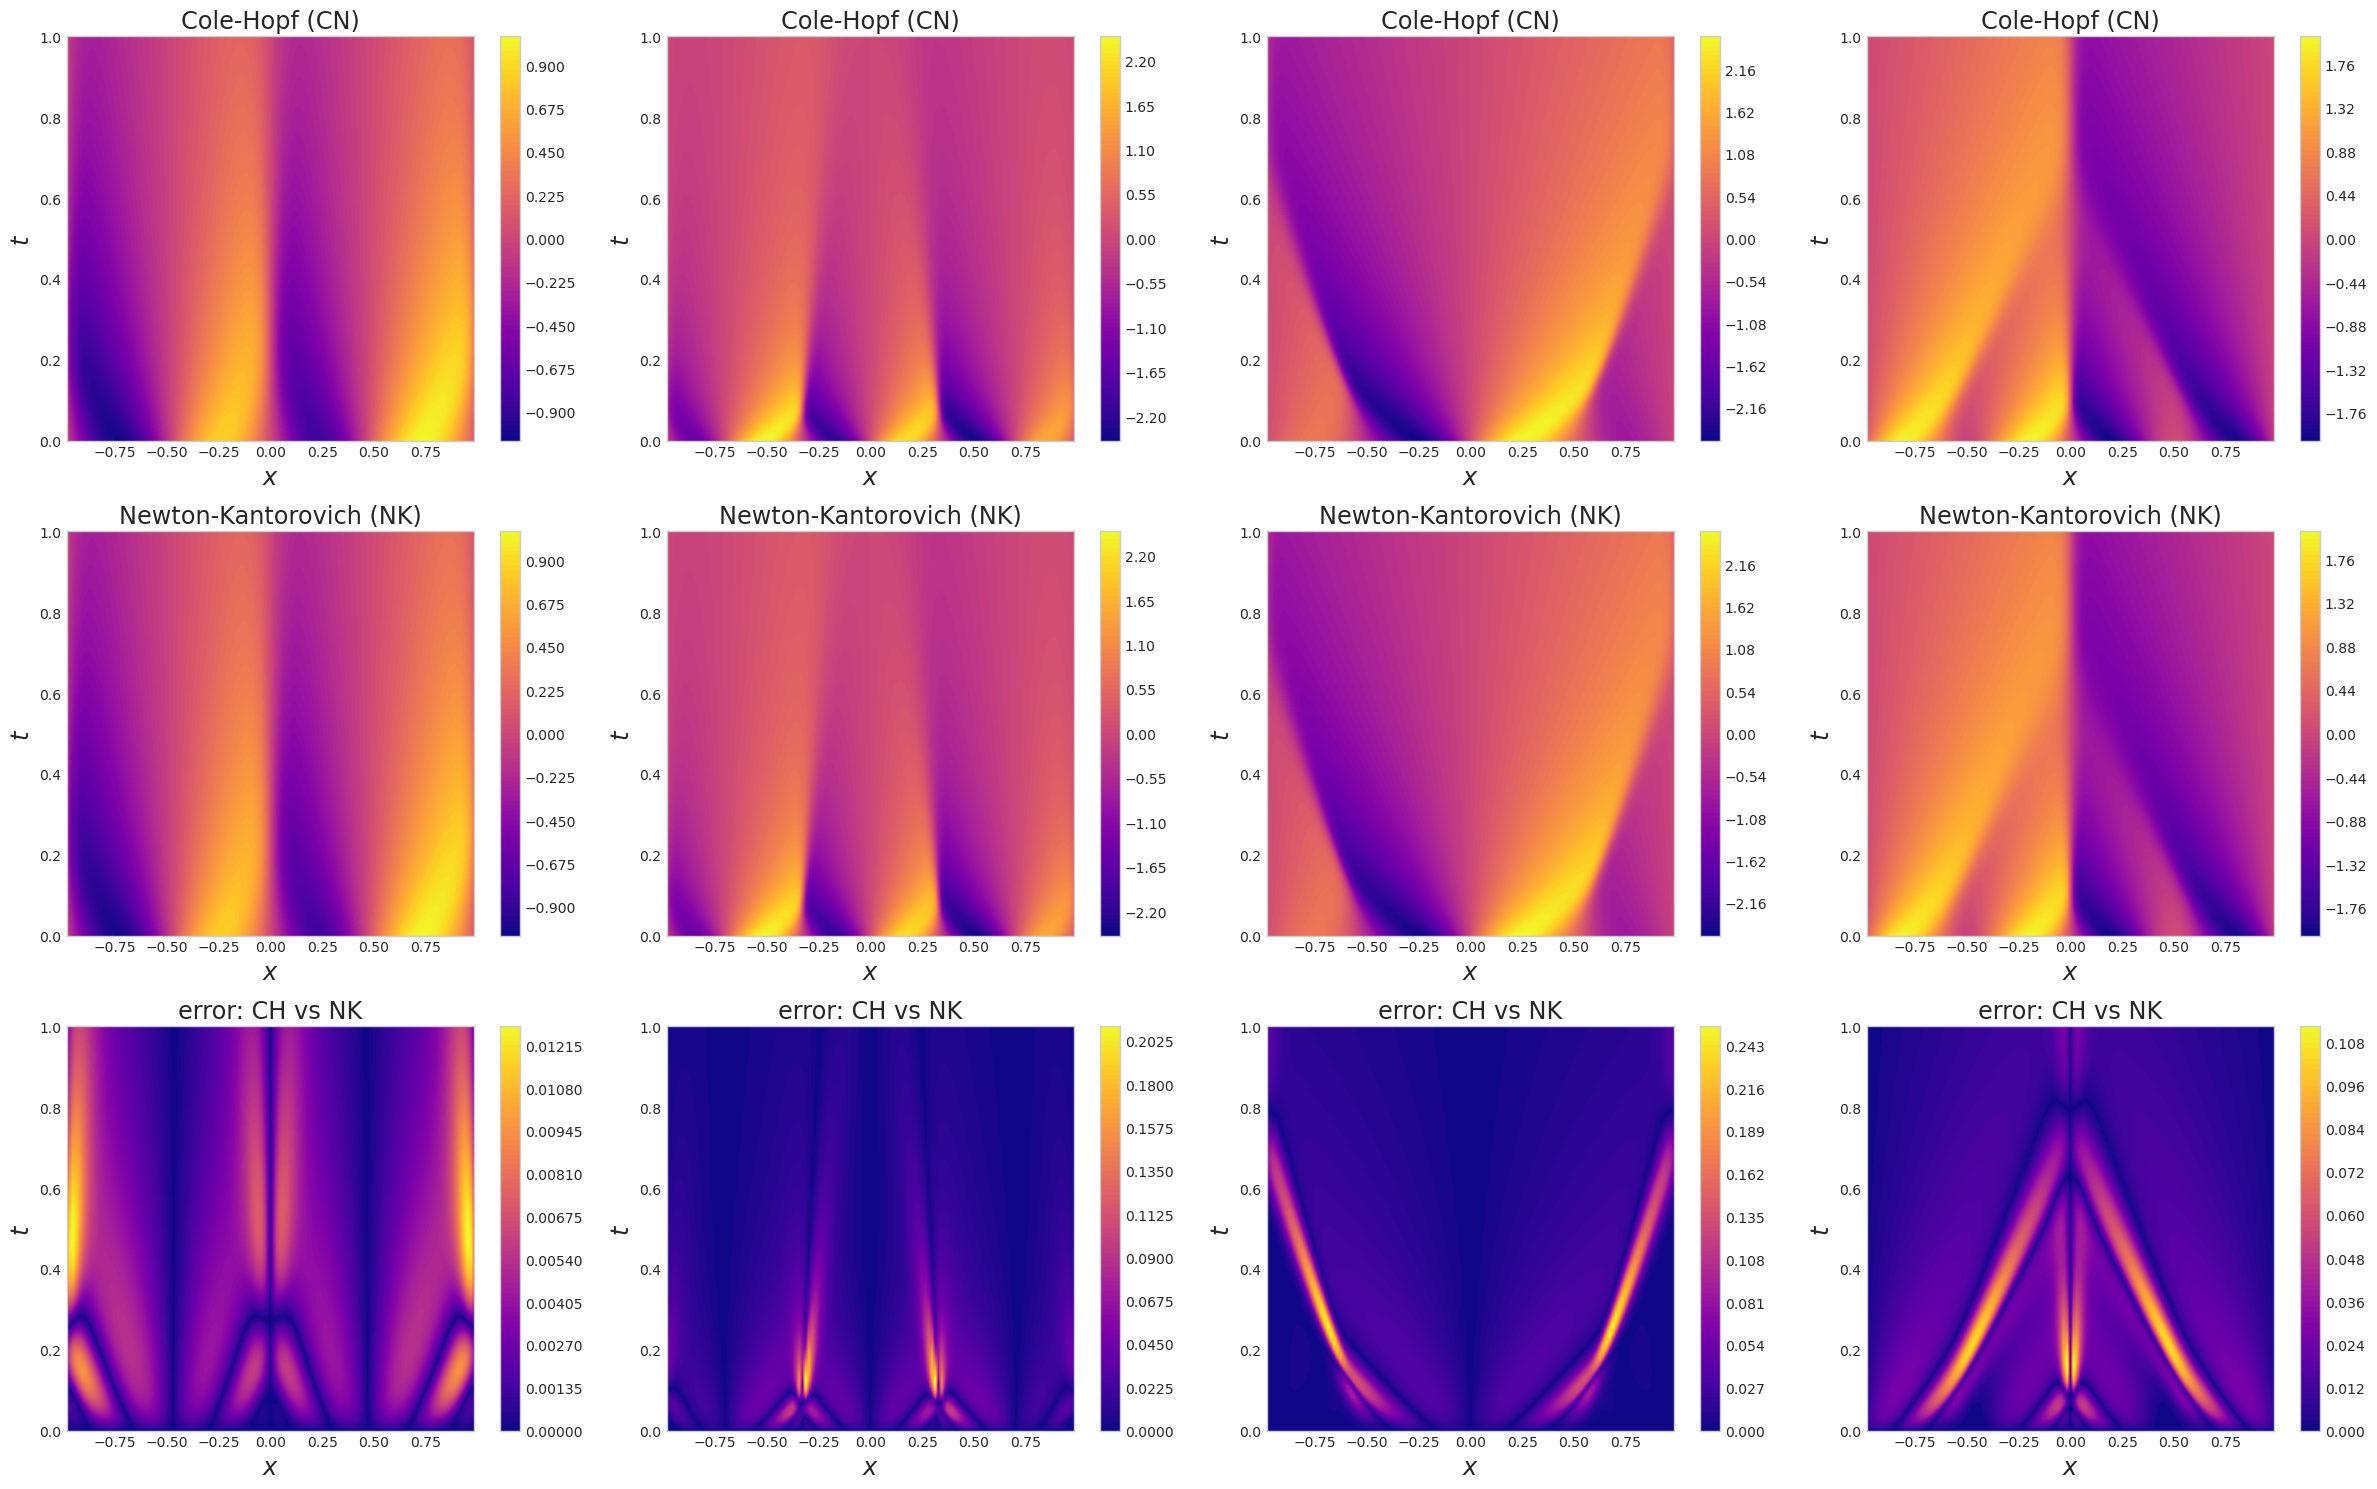

In [ ]:
fig,ax = chonknoris.plot_contourfs(
    data = [
        [(xmesh,tmesh,vref[i]) for i in range(HIGHLIGHTS)],
        [(xmesh,tmesh,vs[i,:,-1,:]) for i in range(HIGHLIGHTS)],
        [(xmesh,tmesh,torch.abs(vs[i,:,-1,:]-vref[i])) for i in range(HIGHLIGHTS)],
    ],
    titles=[[r"Cole-Hopf (CN)"],[r"Newton-Kantorovich (NK)"],[r"error: CH vs NK"]],
    xlabels = r"$x$",
    ylabels = r"$t$",
)

/home/agsorok/DeepNewtonOperator/chonknoris/plots.py:99


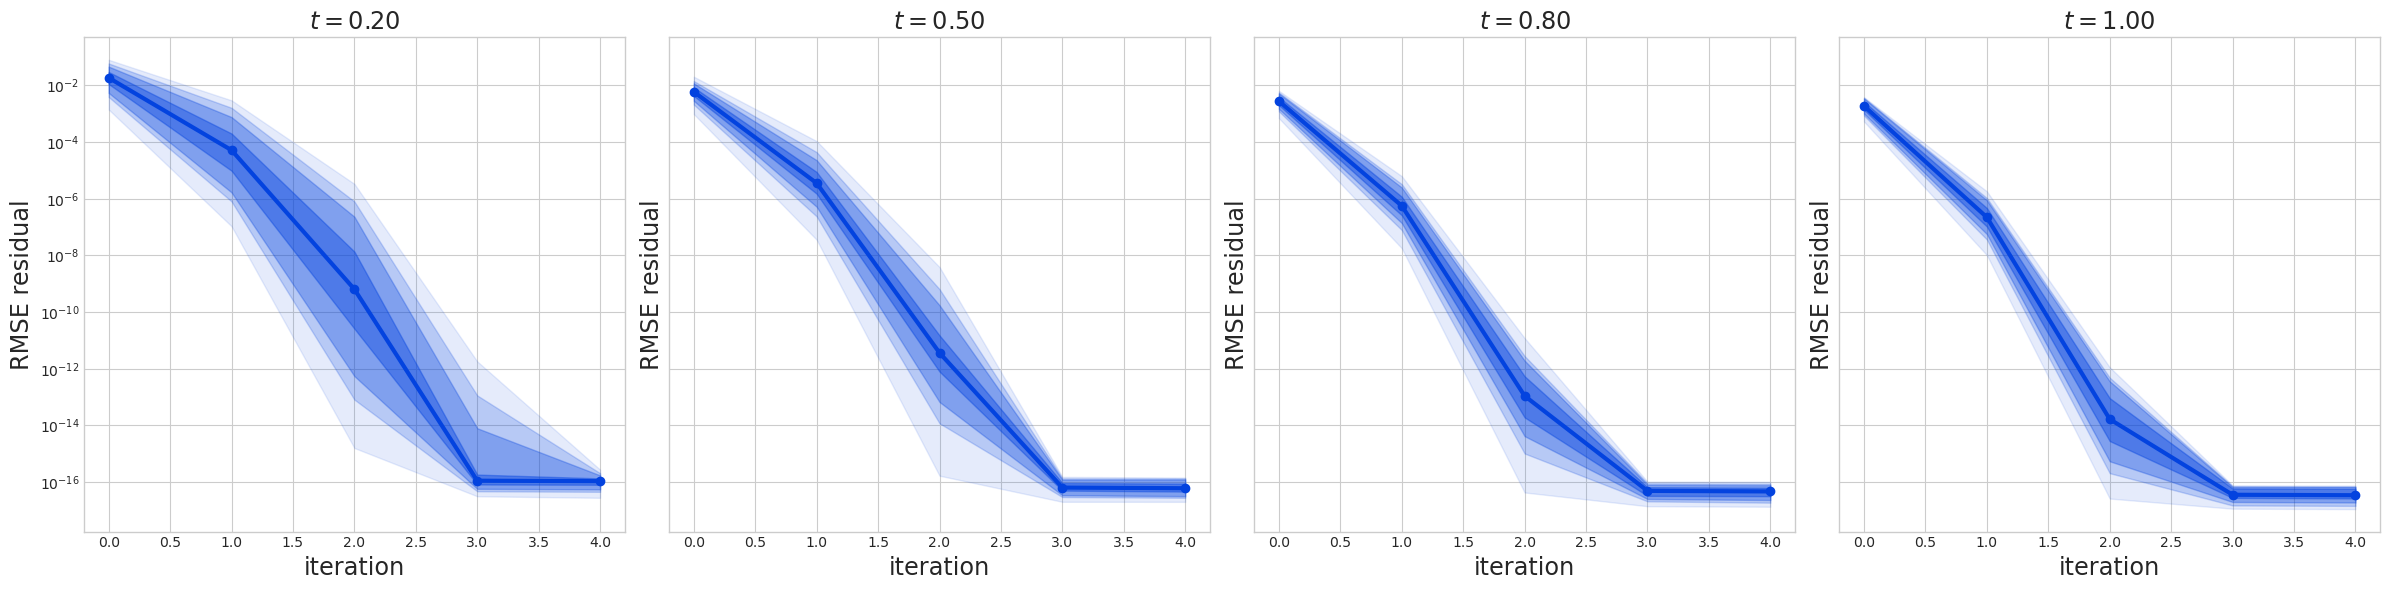

In [ ]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmse_resid"][:,tiplt,:],None)] for tiplt in tpltidxs
        ],
        # [
        #     [(None,data["l2rerrors"][:,tiplt,:],None)] for tiplt in tpltidxs
        # ]
    ],
    xlogscale = False,
    ylogscale = True,
    colors=COLORS,
    sharex=True,
    sharey="row",
    xlabels = "iteration",
    ylabels = "RMSE residual",
        #    [r"$L_2$ relative error"]
    titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
    )
fig.savefig("figs/convergence_nk_solver.pdf")

## Operator learning next pred 

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = ROOT+"/logs/IG/"
name = "MLP"
resume = True

ds_ig_t = chonknoris.DatasetClassic(vs_t[:,:-1,-1,:].flatten(end_dim=-2),vs_t[:,1:,-1,:].flatten(end_dim=-2)-vs_t[:,:-1,-1,:].flatten(end_dim=-2))
ds_ig_v = chonknoris.DatasetClassic(vs_v[:,:-1,-1,:].flatten(end_dim=-2),vs_v[:,1:,-1,:].flatten(end_dim=-2)-vs_v[:,:-1,-1,:].flatten(end_dim=-2))
dl_ig_t = torch.utils.data.DataLoader(ds_ig_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_ig_v = torch.utils.data.DataLoader(ds_ig_v,batch_size=len(ds_ig_v),collate_fn=tuple,shuffle=False)
print("len(ds_ig_t) = %d"%len(ds_ig_t))
print("len(ds_ig_v) = %d"%len(ds_ig_v))

nn_ig_mlp = chonknoris.MLP(mlp_layer_nodes=[Nx]*5,activation_function=torch.nn.Tanh())
lnn_ig_mlp = chonknoris.LightningNN(nn_ig_mlp,lr=1e-5)
print(lnn_ig_mlp)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 800,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_ig_mlp, 
    train_dataloaders = dl_ig_t,
    val_dataloaders = dl_ig_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654
Restoring

len(ds_ig_t) = 67200
len(ds_ig_v) = 9600
LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=127, out_features=127, bias=True)
      (1): Tanh()
      (2): Linear(in_features=127, out_features=127, bias=True)
      (3): Tanh()
      (4): Linear(in_features=127, out_features=127, bias=True)
      (5): Tanh()
      (6): Linear(in_features=127, out_features=127, bias=True)
    )
  )
)



  | Name | Type | Params | Mode 
--------------------------------------
0 | nn   | MLP  | 65.0 K | train
--------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at ././logs/IG//MLP/csv/checkpoints/epoch=799-step=468150.ckpt


/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425
`Trainer.fit` stopped: `max_epochs=800` reached.


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,0.026214,0.026575,0.207908,0.195532,0.000019,0.000024,0.004221,0.004882
25,0.024857,0.026089,0.195425,0.196395,0.000018,0.000023,0.004055,0.004756
50,0.032758,0.026434,0.388217,0.246340,0.000031,0.000024,0.005020,0.004886
75,0.018695,0.020492,0.217897,0.197180,0.000015,0.000016,0.003262,0.004053
100,0.017812,0.021363,0.209837,0.224529,0.000014,0.000016,0.003131,0.004029
125,0.017144,0.019685,0.199357,0.193814,0.000013,0.000016,0.003060,0.003965
150,0.016688,0.017064,0.187216,0.201345,0.000009,0.000011,0.002936,0.003317
175,0.016251,0.016410,0.182765,0.174535,0.000009,0.000011,0.002850,0.003361


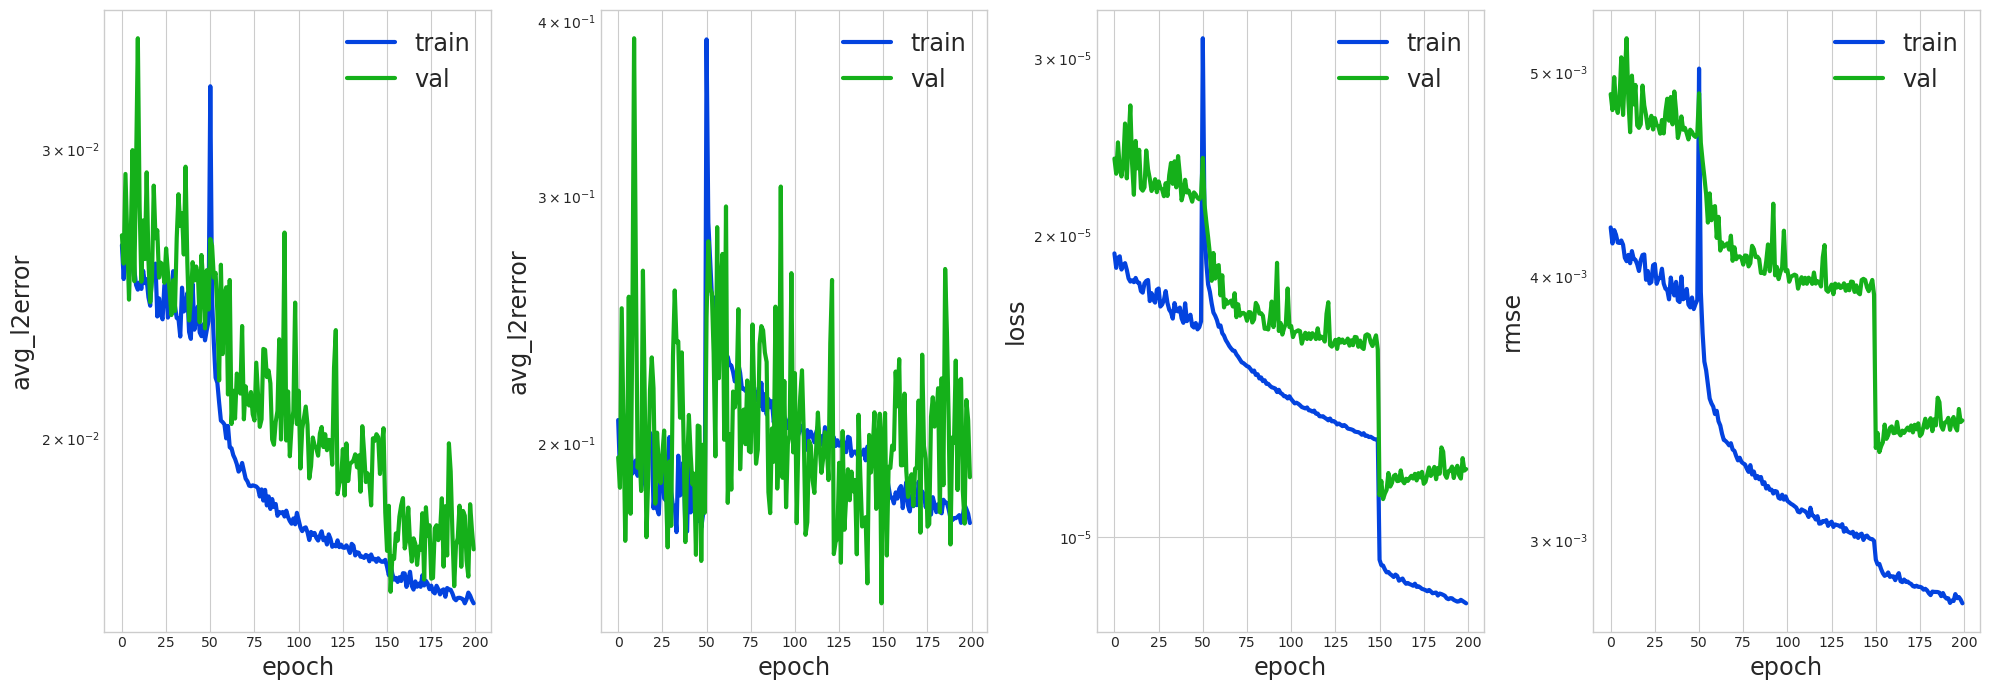

In [ ]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1])
metrics.iloc[::max(1,len(metrics)//8)]

In [ ]:
def v0_pred(u):
    with torch.no_grad(), torch.inference_mode():
        delta = lnn_ig_mlp(u)
    return u+delta
with chonknoris.util.TorchNumThreadsContext(1):
    print("NK")
    vs_v_nk,data_v_nk = pde_solve(u_v,num_newton_iter=4,relaxation=0.,line_search=False,laplace_wraparound=False,deriv_wraparound=False,store_Linvs=False,vref=vs_v[:,:,-1,:],verbose=5,vverbose=30)
    print("IG")
    vs_v_ig,data_v_ig = pde_solve(u_v,v0_pred=v0_pred,num_newton_iter=4,relaxation=0.,line_search=False,laplace_wraparound=False,deriv_wraparound=False,store_Linvs=False,vref=vs_v[:,:,-1,:],verbose=5,vverbose=30)
for key,val in data_v_ig.items():
    print('data_v_ig["%s"].shape = %s'%(key,str(tuple(val.shape))))

NK
    time step 30 of 151: t = 0.19           
    ----------------------------------------
        iter of 4      | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 6.50e-04  | 2.26e-03     2.11e-02     2.32e-02     5.83e-02     | 1.01e-02     2.25e-02     2.53e-02     5.38e-02     |
        4              | 2.09e-02  | 3.15e-17     1.17e-16     1.16e-16     1.91e-16     | 0.00e+00     0.00e+00     0.00e+00     0.00e+00     |
    time step 60 of 151: t = 0.39           
    ----------------------------------------
        iter of 4      | time      | RMSE residual                                       | L

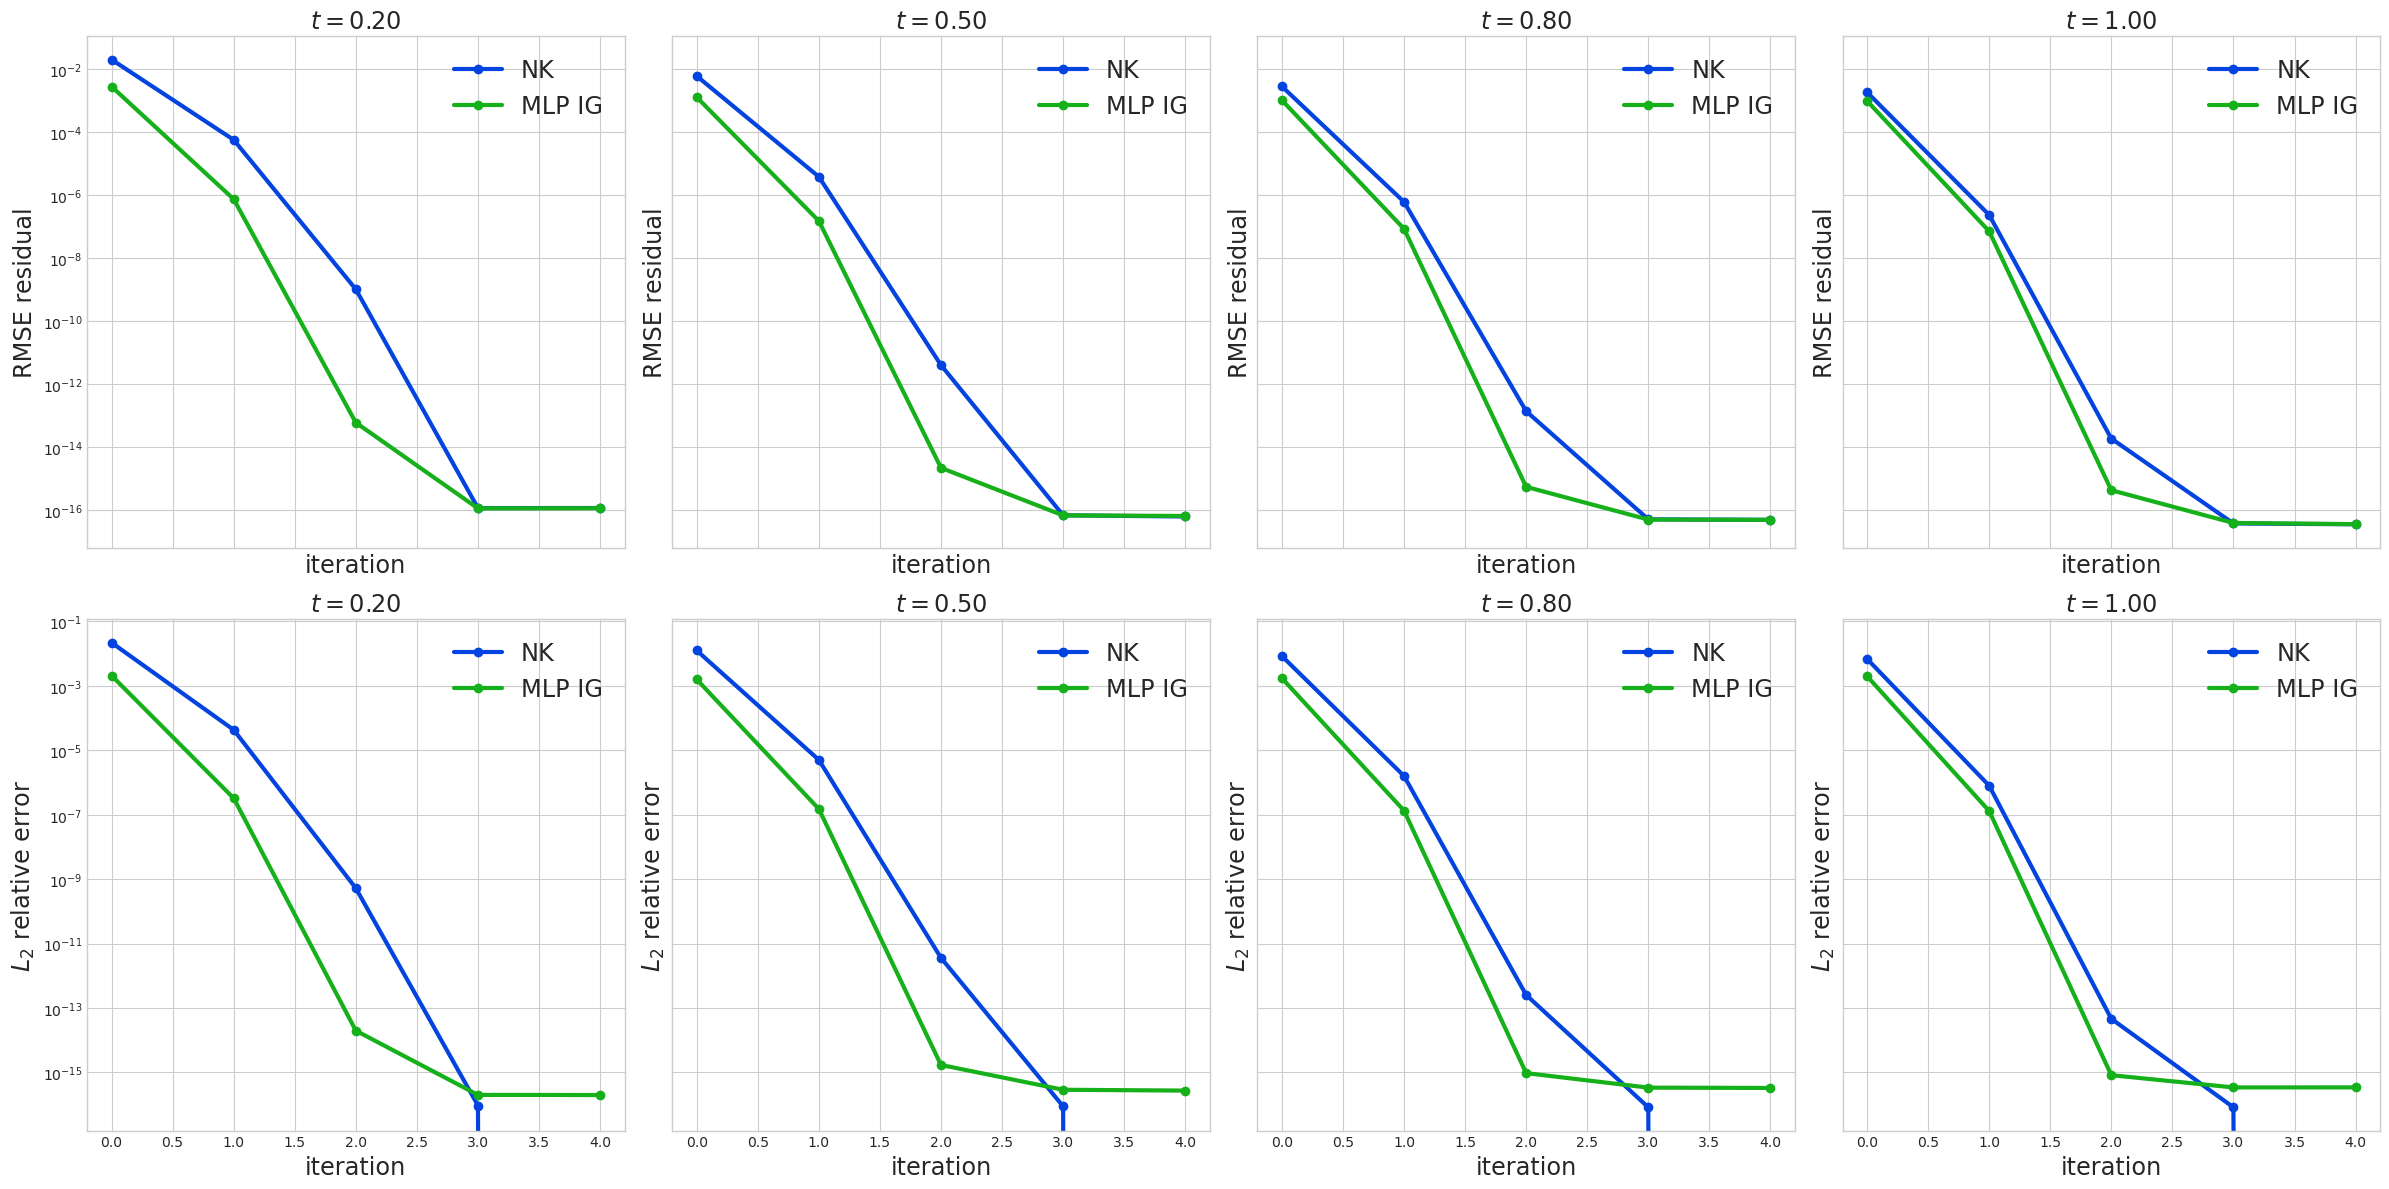

In [ ]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    [
        [[(None,data_v_nk["rmse_resid"][:,tiplt,:],"NK"),(None,data_v_ig["rmse_resid"][:,tiplt,:],"MLP IG")] for tiplt in tpltidxs],
        [[(None,data_v_nk["l2rerrors"][:,tiplt,:],"NK"),(None,data_v_ig["l2rerrors"][:,tiplt,:],"MLP IG")] for tiplt in tpltidxs],
    ],
    xlabels = "iteration",
    ylabels = [["RMSE residual"],[r"$L_2$ relative error"]],
    
    colors=COLORS,
    qhighs=[],
    qlows=[],
    plt_band_alphas=[],
    ylogscale=True,
    sharex=True,
    sharey="row",
    titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
)

## CHONKNORIS Learning

In [ ]:
relaxations = torch.tensor([.01])
SPARSE = False
if SPARSE:
    perm,sparse_lengths = pyKoLesky.cholesky.maximin(x=xticks[:,None],initial=torch.tensor([0.,1.])[:,None])
    sparse_pattern = pyKoLesky.cholesky.sparsity_pattern(xticks[:,None],lengths=sparse_lengths,rho=10)
    perm_inv = torch.argsort(perm) 
    print("sparsity reduction from %d elements to %d elements in Linv"%(
        Nx*(1+Nx)/2,sum(len(col_idxs) for col_idxs in sparse_pattern.values())))
else:
    sparse_pattern = None
    perm = perm_inv = torch.arange(Nx)

In [ ]:
# takes a while to run
ds_Linv_t = chonknoris.DatasetLowerTriMatOpLearn(vs_t[:,1:,:-1].flatten(start_dim=0,end_dim=1),Linvs_t[:,1:].flatten(start_dim=0,end_dim=1),relaxations,sparse=SPARSE,sparse_perm=perm,sparse_pattern=sparse_pattern)
ds_Linv_v = chonknoris.DatasetLowerTriMatOpLearn(vs_v[:,1:,:-1].flatten(start_dim=0,end_dim=1),Linvs_v[:,1:].flatten(start_dim=0,end_dim=1),relaxations,sparse=SPARSE,sparse_perm=perm,sparse_pattern=sparse_pattern)
dl_Linv_t = torch.utils.data.DataLoader(ds_Linv_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_Linv_v = torch.utils.data.DataLoader(ds_Linv_v,batch_size=len(ds_Linv_v),collate_fn=tuple,shuffle=False)
print("len(ds_Linv_t) = %d"%len(ds_Linv_t))
print("len(ds_Linv_v) = %d"%len(ds_Linv_v))

len(ds_Linv_t) = 268800
len(ds_Linv_v) = 38400


### MLP

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = ROOT+"/logs/Linv_"+("SPARSE/" if SPARSE else "FULL/")
name = "MLP"
resume = True

if SPARSE:
  nn_Linv_mlp = chonknoris.MLP(mlp_layer_nodes=[Nx,150,250,350,len(ds_Linv_t._lti0)],activation_function=torch.nn.Tanh())
else:
  nn_Linv_mlp = chonknoris.MLP(mlp_layer_nodes=[Nx,500,1000,len(ds_Linv_t._lti0)],activation_function=torch.nn.Tanh())
lnn_Linv_mlp = chonknoris.LightningNN(nn_Linv_mlp,lr=1e-4,compute_l2errors=False,use_l2rerror_loss=False)
print(lnn_Linv_mlp)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 260,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_Linv_mlp, 
    train_dataloaders = dl_Linv_t,
    val_dataloaders = dl_Linv_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654
Restoring states from the checkpoint path at ././logs/Linv_FULL//MLP/csv/checkpoints/epoch=259-step=185500.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name | Type | Params | Mode 
--------------------------------------
0 | nn   | MLP  | 8.7 M  | train
--------------------------------------
8.7 M     Trainable params
0         Non-trainable params


LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=127, out_features=500, bias=True)
      (1): Tanh()
      (2): Linear(in_features=500, out_features=1000, bias=True)
      (3): Tanh()
      (4): Linear(in_features=1000, out_features=8128, bias=True)
    )
  )
)
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425


/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425
`Trainer.fit` stopped: `max_epochs=260` reached.


,train_loss,val_loss,train_rmse,val_rmse
0,4.050998e-04,3.595197e-05,0.015138,0.005996
32,4.383222e-07,1.142961e-06,0.000648,0.001069
64,2.203248e-07,6.822277e-07,0.000458,0.000826
96,1.523641e-07,5.106394e-07,0.000383,0.000715
128,1.279077e-06,2.994348e-06,0.001123,0.001730
160,1.007271e-06,8.350787e-06,0.000989,0.002890
192,7.324996e-07,7.862893e-06,0.000842,0.002804
224,4.966586e-07,1.498203e-06,0.000602,0.001224
256,1.623920e-07,1.803769e-06,0.000396,0.001343


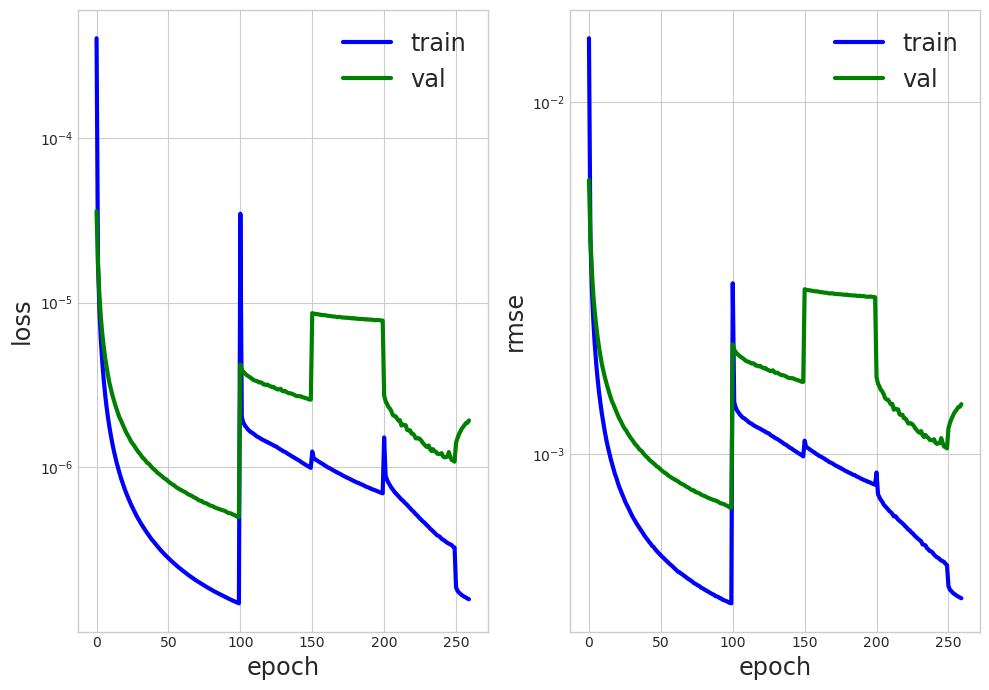

In [ ]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train="b",color_val="g")
metrics.iloc[::max(1,len(metrics)//8)]

### GPR

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = ROOT+"/logs/Linv_"+("SPARSE/" if SPARSE else "FULL/")
name = "GPR"
resume = True

#dl_Linv_exact_t = torch.utils.data.DataLoader(ds_Linv_t,batch_size=2**9,collate_fn=tuple,shuffle=False)
vs_t_full,Linvs_v_full = ds_Linv_t.__getitems__([i for i in range(len(ds_Linv_t))])
gp_Linv_exact_shared_custom = chonknoris.IndepVecGPSharedCustom(d_in=Nx,d_out=len(ds_Linv_t._lti0),
                                                                #noise_lb=1e-4,
                                                                #mean_module = gpytorch.means.ConstantMean(input_size=N),
                                                                #covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=N))
                                                                #covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=3/2,ard_num_dims=N))
                                                                )
lgp_Linv_exact_shared_custom = chonknoris.LightningGPCustom(gp_Linv_exact_shared_custom,lr=1,folds=2,use_l2rerror_loss=True)
print(lgp_Linv_exact_shared_custom)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 3,
    logger = [csv_logger],
    #accelerator = "cpu", # since CUDA runs out of memory 
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lgp_Linv_exact_shared_custom, 
    train_dataloaders = dl_Linv_t,
    val_dataloaders = dl_Linv_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)



Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654
Restoring states from the checkpoint path at ././logs/Linv_FULL//GPR/csv/checkpoints/epoch=1-step=2100.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name | Type                   | Params | Mode 
--------------------------------------------------------
0 | gp   | IndepVecGPSharedCustom | 128    | train
-----------------------------------------------

LightningGPCustom(
  (gp): IndepVecGPSharedCustom(
    (mean_module): ZeroMean()
    (covar_module): ScaleKernel(
      (base_kernel): MaternKernel(
        (raw_lengthscale_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425


/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425


Epoch 2: 100%|██████████| 1050/1050 [00:48<00:00, 21.57it/s, v_num=csv, val_avg_l2error=0.0306, val_avg_l2rerror=0.00418, train_avg_l2error=0.0567, train_avg_l2rerror=0.00847]

`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 1050/1050 [00:48<00:00, 21.56it/s, v_num=csv, val_avg_l2error=0.0306, val_avg_l2rerror=0.00418, train_avg_l2error=0.0567, train_avg_l2rerror=0.00847]


### Inference

In [ ]:
line_search = True
lr = 1.
verbose = 1
vverbose = 25
num_newton_iter = 10
assert len(relaxations)==1, "not sure how to set relaxation for reference solver if there are multiple relaxations"
lgp_Linv_exact_shared_custom.to("cpu")
models = {
    "MLP":nn_Linv_mlp,
    "GPR":gp_Linv_exact_shared_custom,
}
vs_v_chonknoris = {}
data_v_chonknoris = {}
#vs_v_chonknoris_ig = {}
#data_v_chonknoris_ig = {}
for name,model in models.items():
    def predict_Linvs(vs):
        Linvs_hat_sparse = torch.zeros((vs.size(0),Nx,Nx))
        with torch.no_grad(), torch.inference_mode():
            Linvs_hat_sparse_flat_v = model(vs)
        Linvs_hat_sparse[:,ds_Linv_t._lti0,ds_Linv_t._lti1] = Linvs_hat_sparse_flat_v
        Linvs_hat_sparse = Linvs_hat_sparse[:,perm_inv]
        # diag = Linvs_hat_sparse[:,torch.arange(N),torch.arange(N)]
        # diag[diag<0] = 0
        # Linvs_hat_sparse[:,torch.arange(N),torch.arange(N)] = diag
        return Linvs_hat_sparse
    with chonknoris.util.TorchNumThreadsContext(1):
        print("%s CHONKNORIS"%name)
        vs_v_chonknoris[name],data_v_chonknoris[name] = pde_solve(u_v,predict_Linvs=predict_Linvs,num_newton_iter=num_newton_iter,relaxation=0.,line_search=line_search,store_Linvs=False,vref=vs_v[:,:,-1,:],verbose=verbose,vverbose=vverbose)
        # print("%s CHONKNORIS + IG"%name) 
        # vs_v_chonknoris_ig[name],data_v_chonknoris_ig[name] = pde_solve(u_v,v0_pred=v0_pred,predict_Linvs=predict_Linvs,num_newton_iter=num_newton_iter,relaxation=0.,line_search=line_search,store_Linvs=False,vref=vs_v[:,:,-1,:],verbose=verbose,vverbose=vverbose)


MLP CHONKNORIS
    time step 25 of 151: t = 0.16           
    ----------------------------------------
        iter of 10     | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 8.23e-04  | 2.44e-03     2.28e-02     2.74e-02     7.37e-02     | 1.05e-02     2.31e-02     2.78e-02     6.13e-02     |
        1              | 2.74e-02  | 2.32e-05     2.94e-04     8.91e-04     4.75e-03     | 8.57e-05     2.78e-04     9.60e-04     2.42e-03     |
        2              | 2.74e-02  | 2.20e-07     4.72e-06     7.41e-05     3.83e-04     | 8.09e-07     4.38e-06     4.91e-04     2.64e-04     |
        3              | 

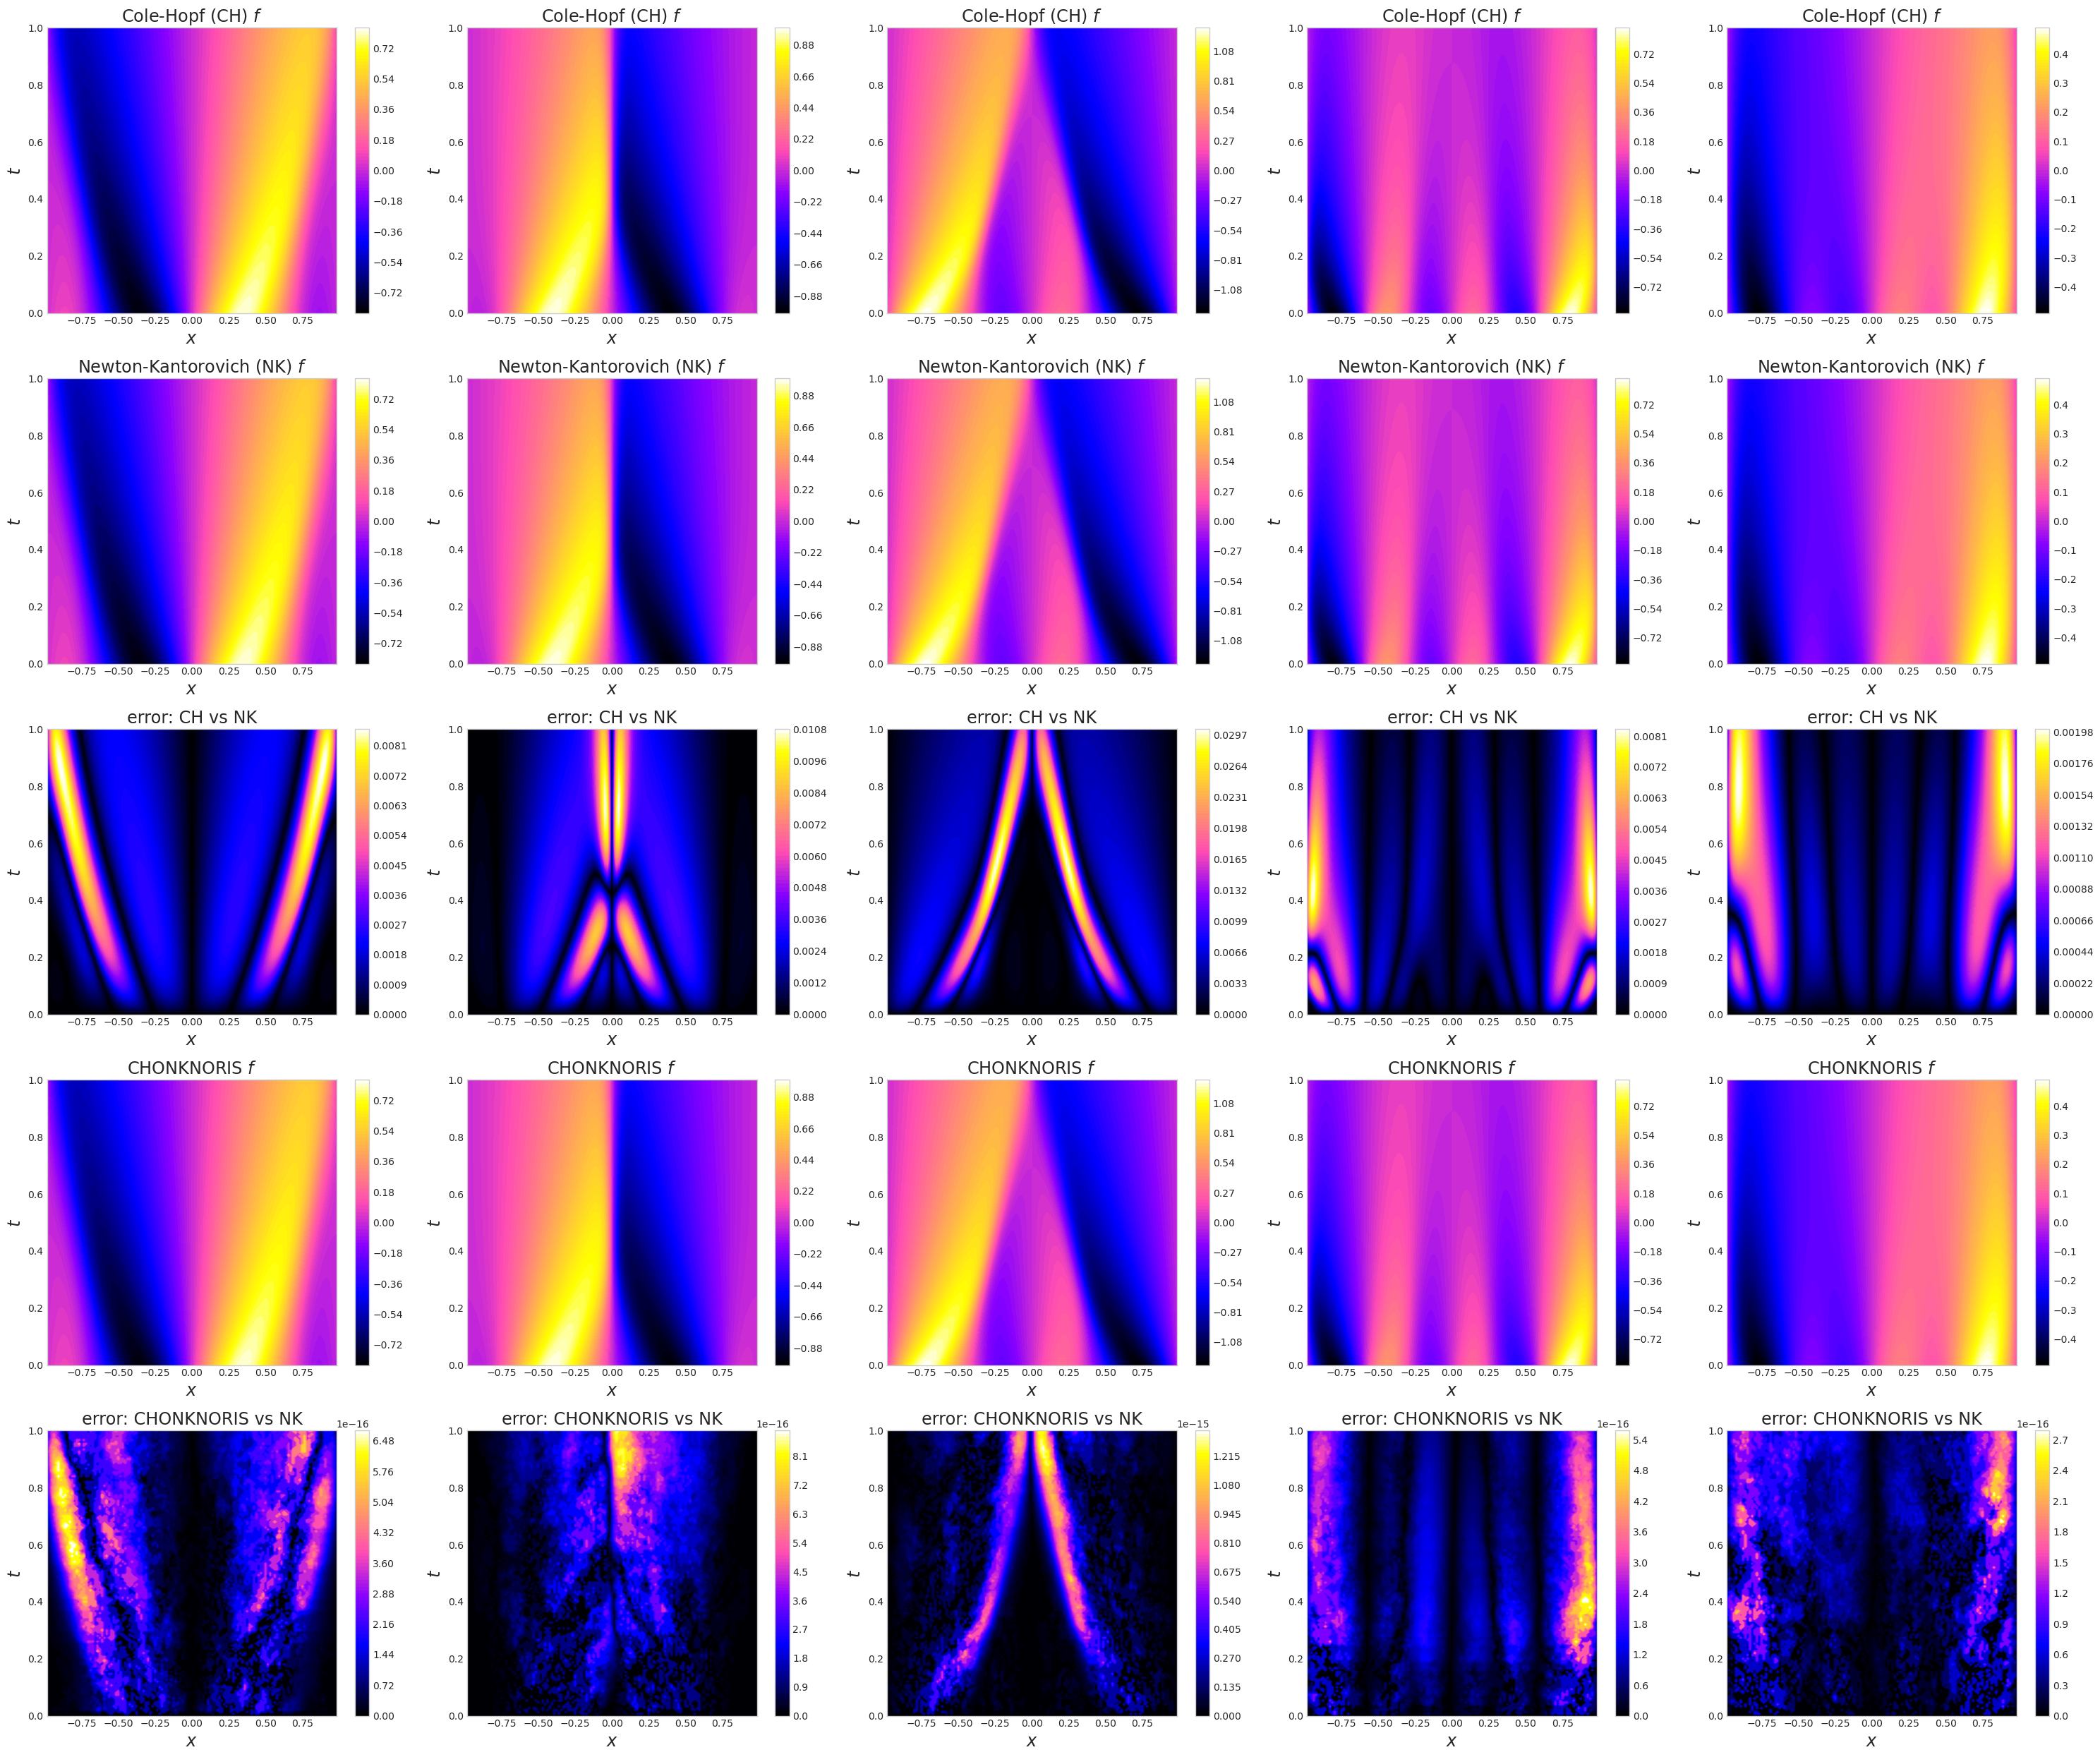

In [ ]:
SHOWIDXS = [1,2,3,6,8]
name = "GPR"
fig,ax = chonknoris.plot_contourfs(
    data = [
        [(xmesh,tmesh,vref[vidx[i]]) for i in SHOWIDXS],
        [(xmesh,tmesh,vs_v_nk[i,:,-1,:]) for i in SHOWIDXS],
        [(xmesh,tmesh,torch.abs(vref[vidx[i]]-vs_v_nk[i,:,-1,:])) for i in SHOWIDXS],
        [(xmesh,tmesh,vs_v_chonknoris[name][i,:,-1,:]) for i in SHOWIDXS],
        [(xmesh,tmesh,torch.abs(vs_v_chonknoris[name][i,:,-1,:]-vs_v_nk[i,:,-1,:])) for i in SHOWIDXS],
    ],
    xlabels = r"$x$",
    ylabels = r"$t$",
    titles = [[r"Cole-Hopf (CH) $f$"],[r"Newton-Kantorovich (NK) $f$"],["error: CH vs NK"],[r"CHONKNORIS $f$"],["error: CHONKNORIS vs NK"]],
    cmap = cm.gnuplot2,
)
fig.savefig("figs/CHONKNORIS_error.png",dpi=256)

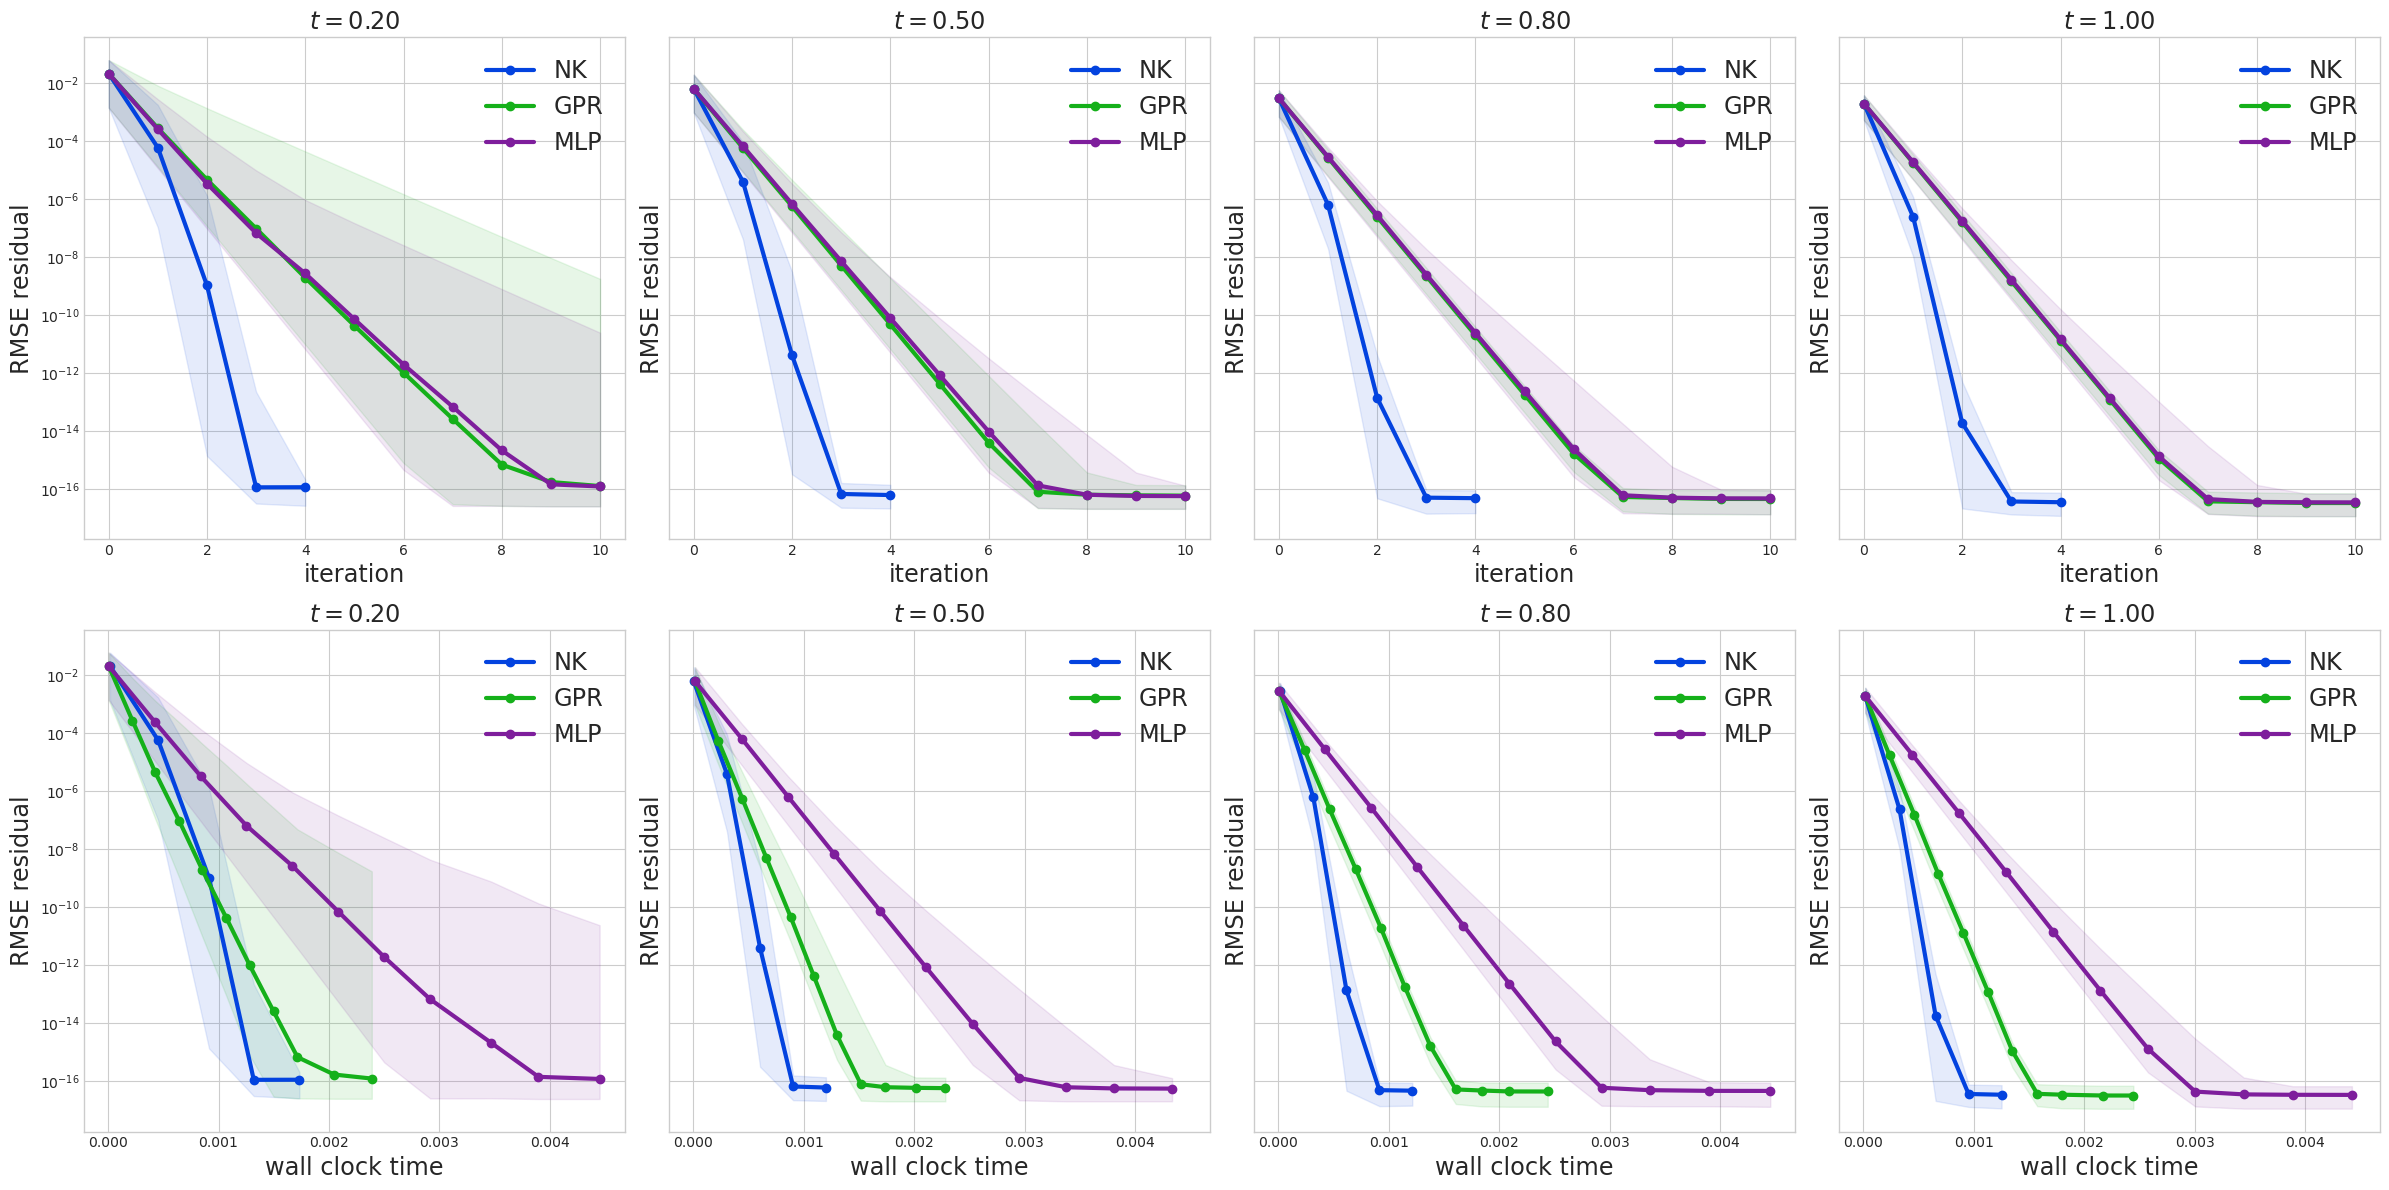

In [ ]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    [
        [
            [
                (None,data_v_nk["rmse_resid"][:,tiplt,:],"NK"),
                (None,data_v_chonknoris["GPR"]["rmse_resid"][:,tiplt,:],"GPR"),
                (None,data_v_chonknoris["MLP"]["rmse_resid"][:,tiplt,:],"MLP"),
                #(None,data_v_ig["rmse_resid"][:,tiplt,:],"MLP IG"),
                #(None,data_v_chonknoris_ig["rmse_resid"][:,tiplt,:],"CHONKNORIS IG"),
            ]
        for tiplt in tpltidxs],
        [
            [
                (data_v_nk["times"][tiplt]-data_v_nk["times"][tiplt-1,-1],data_v_nk["rmse_resid"][:,tiplt,:],"NK"),
                (data_v_chonknoris["GPR"]["times"][tiplt]-data_v_chonknoris["GPR"]["times"][tiplt-1,-1],data_v_chonknoris["GPR"]["rmse_resid"][:,tiplt,:],"GPR"),
                (data_v_chonknoris["MLP"]["times"][tiplt]-data_v_chonknoris["MLP"]["times"][tiplt-1,-1],data_v_chonknoris["MLP"]["rmse_resid"][:,tiplt,:],"MLP"),
                #(data_v_ig["times"][tiplt]-data_v_ig["times"][tiplt-1,-1],data_v_ig["rmse_resid"][:,tiplt,:],"MLP IG"),
                #(data_v_chonknoris_ig["times"][tiplt]-data_v_chonknoris_ig["times"][tiplt-1,-1],data_v_chonknoris_ig["rmse_resid"][:,tiplt,:],"CHONKNORIS IG"),
            ]
        for tiplt in tpltidxs],
    ],
    xlabels = [["iteration"],["wall clock time"]],
    ylabels = "RMSE residual",
    colors=COLORS,
    qhighs=[.99],
    qlows=[.01],
    #plt_band_alphas=[],
    ylogscale=True,
    sharex="row",
    sharey=True,
    titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
)
fig.savefig("figs/CHONKNORIS_convergence.pdf")

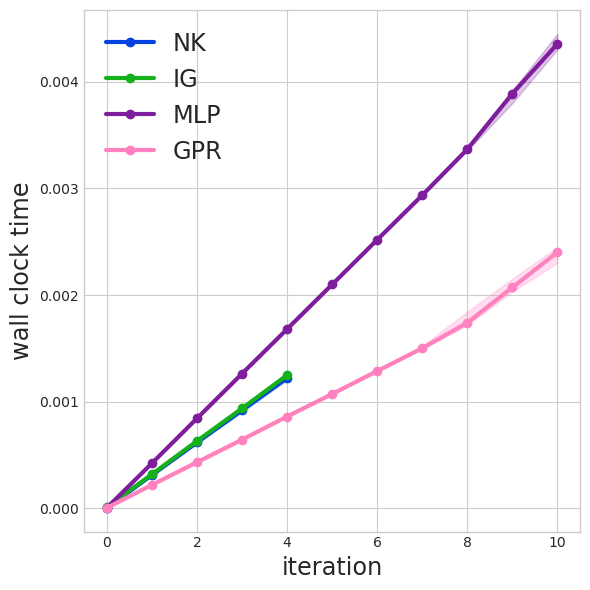

In [ ]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    [
        [
            [
                (None,data_v_nk["times"][1:]-data_v_nk["times"][:-1,-1,None],"NK"),
                (None,data_v_ig["times"][1:]-data_v_ig["times"][:-1,-1,None],"IG"),
                (None,data_v_chonknoris["MLP"]["times"][1:]-data_v_chonknoris["MLP"]["times"][:-1,-1,None],"MLP"),
                (None,data_v_chonknoris["GPR"]["times"][1:]-data_v_chonknoris["GPR"]["times"][:-1,-1,None],"GPR"),
            ]
        ],
    ],
    xlabels = "iteration",
    ylabels = "wall clock time",
    colors=COLORS,
    qhighs=[.75],
    qlows=[.25],
    plt_band_alphas=[.25],
    xlogscale=False,
    ylogscale=False,
    plot_mean=False,
    plot_median=True,
    #sharex=True,
    #sharey="row",
    #titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
)